# Water Station Parameters Discovery

## 🎯 Objective
Systematically discover what water measurement parameters are available at monitoring stations near our river erosion scope regions.

## 📋 Deliverables
1. **Parameter inventory** - Complete list of available parameters with station counts
2. **Spatial coverage analysis** - Which parameters are available in our scope regions
3. **Priority parameter selection** - Water height, discharge, and other useful parameters
4. **Station categorization** - Which stations measure which parameters
5. **GeoPackage outputs** - Separate layers for each parameter type

## 🚫 Out of Scope (for this notebook)
- Bulk time series downloading (that's for a separate notebook)
- Feature engineering
- Data quality analysis beyond basic checks

---

## 📚 Working Hypothesis
**Active stations that measure water height are likely to also measure other parameters (discharge, temperature, etc.).**

We'll test this hypothesis and document the actual parameter coverage.

---

## 1. Setup & Configuration

In [2]:
# Imports
import sys
sys.path.insert(0, "..")
sys.path.append("../..")

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import requests
from datetime import datetime
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10

print("✅ Imports successful!")

✅ Imports successful!


In [3]:
# Import paths
import src.paths as PATHS

In [18]:
# Configuration
SCOPE_GPKG = PATHS.DATA_DIR / "wocu_output_fase2_v4.gpkg"
OUTPUT_DIR = PATHS.DATA_DIR / "water_stations_by_parameter"
OUTPUT_DIR.mkdir(exist_ok=True)

# RWS WFS Service
WFS_URL = "https://waterwebservices.rijkswaterstaat.nl/METADATASERVICES_DBO/OphalenCatalogus/"

# Waterweb API
BASE_URL = "https://ddapi20-waterwebservices.rijkswaterstaat.nl"
OBSERVATIONS_ENDPOINT = f"{BASE_URL}/ONLINEWAARNEMINGENSERVICES/OphalenWaarnemingen"
CATALOG_ENDPOINT = f"{BASE_URL}/METADATASERVICES_DBO/OphalenCatalogus"
HEADERS = {
    "Content-Type": "application/json",
    "X-API-KEY": "dummy-key"
}

# Spatial analysis
BUFFER_DISTANCE = 100  # meters around scope regions
ACTIVE_SINCE_YEAR = 2015  # Filter for stations active since this year

print(f"📂 Scope regions: {SCOPE_GPKG}")
print(f"📁 Output directory: {OUTPUT_DIR}")
print(f"📏 Buffer distance: {BUFFER_DISTANCE}m")
print(f"📅 Active stations: >= {ACTIVE_SINCE_YEAR}")

📂 Scope regions: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/wocu_output_fase2_v4.gpkg
📁 Output directory: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_by_parameter
📏 Buffer distance: 100m
📅 Active stations: >= 2015


## 2. Load All WFS Stations

Download the complete list of water monitoring stations from RWS WFS service.

In [48]:
print("📡 Downloading all water stations from RWS WFS service...\n")

# Use the OGC WFS service (not the catalog API!)
WFS_BASE_URL = "https://geo.rijkswaterstaat.nl/services/ogc/hws/DDAPI20/ows"
WFS_PARAMS = {
    'SERVICE': 'WFS',
    'VERSION': '1.1.0',
    'REQUEST': 'GetFeature',
    'TYPENAME': 'locatiesmetlaatstewaarneming',
    'OUTPUTFORMAT': 'csv',
    'SRSNAME': 'EPSG:28992'  # REQUEST RD New coordinates!
}

print(f"   Service: {WFS_BASE_URL}")
print(f"   Layer: {WFS_PARAMS['TYPENAME']}")
print(f"   Coordinate System: {WFS_PARAMS['SRSNAME']}")
print(f"   This may take 30-60 seconds...\n")

try:
    from io import StringIO
    
    response = requests.get(WFS_BASE_URL, params=WFS_PARAMS, timeout=120)
    response.raise_for_status()
    
    # Parse CSV
    all_stations_df = pd.read_csv(StringIO(response.text), low_memory=False)
    
    print(f"✅ Downloaded {len(all_stations_df):,} stations\n")
    
    # Check sample geometry to verify coordinate system
    if 'GEOMETRY' in all_stations_df.columns:
        from shapely import wkt
        sample_geom = wkt.loads(all_stations_df['GEOMETRY'].iloc[0])
        print(f"📋 Sample geometry: {sample_geom}")
        print(f"   Coordinates should be in RD New range (0-300000, 300000-625000)\n")
    
    print(f"📊 Key columns:")
    print(f"   • CODE: {all_stations_df['CODE'].iloc[0]}")
    print(f"   • NAAM: {all_stations_df['NAAM'].iloc[0]}")
    print(f"   • PARAMETER_WAT_OMSCHRIJVING: {all_stations_df['PARAMETER_WAT_OMSCHRIJVING'].iloc[0][:60]}...")
    
    print(f"\n📊 Top 10 parameters:")
    param_summary = all_stations_df.groupby('PARAMETER_WAT_OMSCHRIJVING').size().sort_values(ascending=False)
    for param, count in param_summary.head(10).items():
        print(f"   • {param[:80]}: {count:,} stations")
    
except Exception as e:
    print(f"❌ Failed to download: {e}")
    import traceback
    traceback.print_exc()
    all_stations_df = pd.DataFrame()

📡 Downloading all water stations from RWS WFS service...

   Service: https://geo.rijkswaterstaat.nl/services/ogc/hws/DDAPI20/ows
   Layer: locatiesmetlaatstewaarneming
   Coordinate System: EPSG:28992
   This may take 30-60 seconds...

✅ Downloaded 916,732 stations

📋 Sample geometry: POINT (217101.0504193791 585125.923958278)
   Coordinates should be in RD New range (0-300000, 300000-625000)

📊 Key columns:
   • CODE: grijpskerk.gaarkeuken.oost
   • NAAM: Grijpskerk Gaarkeuken oost
   • PARAMETER_WAT_OMSCHRIJVING: Waterhoogte in Oppervlaktewater t.o.v. Normaal Amsterdams Pe...

📊 Top 10 parameters:
   • Temperatuur in Oppervlaktewater in oC: 88,163 stations
   • Zuurgraad in Oppervlaktewater: 86,628 stations
   • Geleidendheid in Oppervlaktewater in mS/m: 85,853 stations
   • Verzadigingsgraad zuurstof in Oppervlaktewater in %: 85,433 stations
   • (massa)Concentratie zuurstof in Oppervlaktewater in mg/l: 84,555 stations
   • Saliniteit in Oppervlaktewater: 83,484 stations
   • (mass

In [50]:
# Preview the data
print("📋 Sample of downloaded data:\n")
print(all_stations_df.head(10))
print("\n📊 Data types:")
print(all_stations_df.dtypes)

📋 Sample of downloaded data:

                                                 FID  WAARNEMING_ID  \
0  locatiesmetlaatstewaarneming.fid-4c8ea8d7_19c5...            375   
1  locatiesmetlaatstewaarneming.fid-4c8ea8d7_19c5...            649   
2  locatiesmetlaatstewaarneming.fid-4c8ea8d7_19c5...            750   
3  locatiesmetlaatstewaarneming.fid-4c8ea8d7_19c5...            838   
4  locatiesmetlaatstewaarneming.fid-4c8ea8d7_19c5...            918   
5  locatiesmetlaatstewaarneming.fid-4c8ea8d7_19c5...            992   
6  locatiesmetlaatstewaarneming.fid-4c8ea8d7_19c5...           1060   
7  locatiesmetlaatstewaarneming.fid-4c8ea8d7_19c5...           1124   
8  locatiesmetlaatstewaarneming.fid-4c8ea8d7_19c5...           1185   
9  locatiesmetlaatstewaarneming.fid-4c8ea8d7_19c5...           1243   

                           NAAM                        CODE  \
0    Grijpskerk Gaarkeuken oost  grijpskerk.gaarkeuken.oost   
1       Dordrecht Oude Maas 120      dordrecht.oudemaas.120   

## 3. Parameter Inventory Analysis

What parameters are available? How many stations measure each parameter?

In [51]:
print("="*80)
print("PARAMETER INVENTORY")
print("="*80)

# Group by parameter description (no parameter code in this dataset)
parameter_summary = all_stations_df.groupby('PARAMETER_WAT_OMSCHRIJVING').agg({
    'CODE': 'nunique'
}).reset_index()
parameter_summary.columns = ['Parameter_Description', 'Num_Stations']
parameter_summary = parameter_summary.sort_values('Num_Stations', ascending=False)

print(f"\n📊 Total unique parameters: {len(parameter_summary)}\n")
print(f"📋 Top 20 parameters by station count:\n")
print(parameter_summary.head(20).to_string(index=False))

# Save full inventory
inventory_path = OUTPUT_DIR / "parameter_inventory_full.csv"
parameter_summary.to_csv(inventory_path, index=False)
print(f"\n💾 Full inventory saved to: {inventory_path}")

PARAMETER INVENTORY

📊 Total unique parameters: 2437

📋 Top 20 parameters by station count:

                                                                                            Parameter_Description  Num_Stations
                                                                            Temperatuur in Oppervlaktewater in oC          1094
                                                                                    Zuurgraad in Oppervlaktewater           787
                                             Waterhoogte in Oppervlaktewater t.o.v. Normaal Amsterdams Peil in cm           759
                                                         (massa)Concentratie zuurstof in Oppervlaktewater in mg/l           752
                                                              Verzadigingsgraad zuurstof in Oppervlaktewater in %           711
              (massa)Concentratie ammonium in Oppervlaktewater uitgedrukt in stikstof / opgeloste fractie in mg/l           502
           


📊 Visualizing parameter distribution...



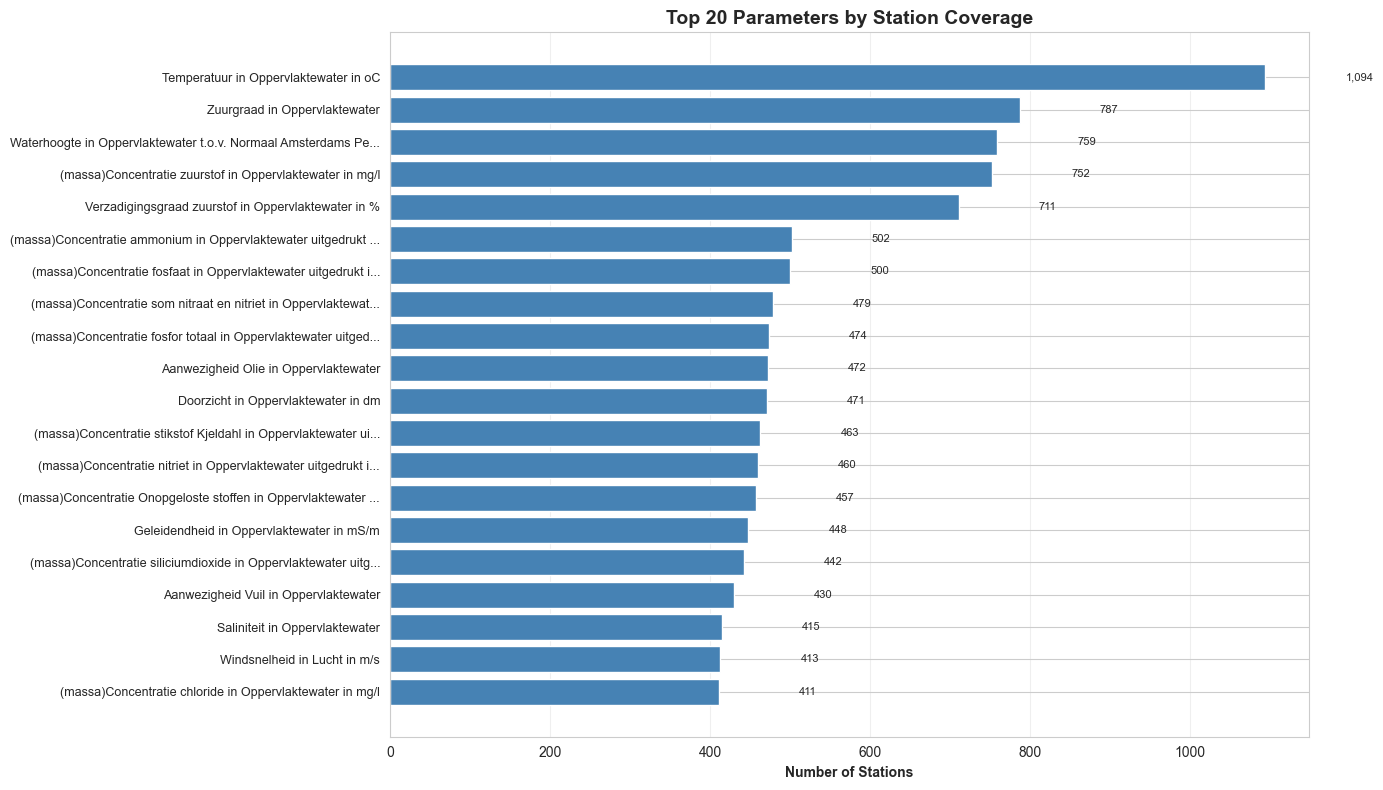

In [52]:
# Visualize top parameters
print("\n📊 Visualizing parameter distribution...\n")

fig, ax = plt.subplots(figsize=(14, 8))
top_20 = parameter_summary.head(20)
ax.barh(range(len(top_20)), top_20['Num_Stations'], color='steelblue')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels([f"{row['Parameter_Description'][:60]}..." 
                     if len(row['Parameter_Description']) > 60 
                     else row['Parameter_Description']
                     for _, row in top_20.iterrows()], fontsize=9)
ax.set_xlabel('Number of Stations', fontweight='bold')
ax.set_title('Top 20 Parameters by Station Coverage', fontweight='bold', fontsize=14)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (_, row) in enumerate(top_20.iterrows()):
    ax.text(row['Num_Stations'] + 100, i, f"{row['Num_Stations']:,}", 
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Load Scope Regions & Spatial Filtering

Filter stations to only those within our study area (100m buffer around scope regions).

In [53]:
print("📥 Loading scope regions...\n")

scope_regions = gpd.read_file(SCOPE_GPKG, layer='vlakken_scope')

print(f"✅ Loaded {len(scope_regions)} scope regions")
print(f"📐 CRS: {scope_regions.crs}")
print(f"📊 Columns: {list(scope_regions.columns)}\n")

📥 Loading scope regions...

✅ Loaded 12130 scope regions
📐 CRS: EPSG:28992
📊 Columns: ['position_id', 'waterlichaam', 'geometry']



In [54]:
print("🗺️ Converting station data to GeoDataFrame...\n")

from shapely import wkt

# Filter out records with missing geometry
stations_with_geom = all_stations_df[all_stations_df['GEOMETRY'].notna()].copy()

print(f"📍 Stations with valid geometry: {len(stations_with_geom):,}")

# Parse WKT geometry - already in EPSG:28992!
all_stations_gdf = gpd.GeoDataFrame(
    stations_with_geom,
    geometry=stations_with_geom['GEOMETRY'].apply(wkt.loads),
    crs='EPSG:28992'
)

print(f"✅ Created GeoDataFrame with {len(all_stations_gdf):,} records")
print(f"📐 CRS: {all_stations_gdf.crs}")
print(f"📊 Bounds: {all_stations_gdf.total_bounds}")
print(f"📋 Sample coordinates:")
print(all_stations_gdf[['CODE', 'NAAM', 'geometry']].head())

🗺️ Converting station data to GeoDataFrame...

📍 Stations with valid geometry: 916,732
✅ Created GeoDataFrame with 916,732 records
📐 CRS: EPSG:28992
📊 Bounds: [-8803488.9998072   -356245.0667026    279390.02714101   823483.86167337]
📋 Sample coordinates:
                         CODE                        NAAM  \
0  grijpskerk.gaarkeuken.oost  Grijpskerk Gaarkeuken oost   
1      dordrecht.oudemaas.120     Dordrecht Oude Maas 120   
2                europlatform                Europlatform   
3        dalfsen.vechterweerd       Dalfsen, Vechterweerd   
4              europlatform.3              Europlatform 3   

                        geometry  
0   POINT (217101.05 585125.924)  
1  POINT (103359.027 424187.082)  
2    POINT (9962.794 447600.766)  
3  POINT (210960.027 503700.036)  
4     POINT (9372.26 447616.865)  


In [55]:
print("🔍 Debugging spatial join...\n")

print("📊 Scope regions:")
print(f"   CRS: {scope_regions.crs}")
print(f"   Total bounds: {scope_regions.total_bounds}")
print(f"   Sample geometry: {scope_regions.geometry.iloc[0]}")

print("\n📊 Station data:")
print(f"   CRS: {all_stations_gdf.crs}")
print(f"   Total bounds: {all_stations_gdf.total_bounds}")
print(f"   Sample geometry: {all_stations_gdf.geometry.iloc[0]}")

# Check if any stations are near scope regions
print("\n🔍 Checking for overlap...")
scope_bbox = scope_regions.total_bounds
stations_bbox = all_stations_gdf.total_bounds

print(f"\nScope bbox: [{scope_bbox[0]:.0f}, {scope_bbox[1]:.0f}, {scope_bbox[2]:.0f}, {scope_bbox[3]:.0f}]")
print(f"Stations bbox: [{stations_bbox[0]:.0f}, {stations_bbox[1]:.0f}, {stations_bbox[2]:.0f}, {stations_bbox[3]:.0f}]")

# Check if bboxes overlap
if (scope_bbox[0] > stations_bbox[2] or scope_bbox[2] < stations_bbox[0] or
    scope_bbox[1] > stations_bbox[3] or scope_bbox[3] < stations_bbox[1]):
    print("\n❌ Bounding boxes DO NOT overlap - CRS mismatch likely!")
else:
    print("\n✅ Bounding boxes overlap - should find matches")

print("\n🔍 Performing spatial join with scope regions...\n")

# Buffer scope regions
scope_buffered = scope_regions.copy()
scope_buffered['geometry'] = scope_buffered.geometry.buffer(BUFFER_DISTANCE)

# Try with 'intersects' instead of 'within'
stations_in_scope = gpd.sjoin(
    all_stations_gdf,
    scope_buffered,
    how='inner',
    predicate='intersects'  # Changed from 'within'
)

print(f"✅ Found {len(stations_in_scope):,} station-parameter records in scope regions")
print(f"📍 Unique locations in scope: {stations_in_scope['CODE'].nunique():,}")
print(f"🔬 Unique parameters in scope: {stations_in_scope['PARAMETER_WAT_OMSCHRIJVING'].nunique():,}\n")

🔍 Debugging spatial join...

📊 Scope regions:
   CRS: EPSG:28992
   Total bounds: [102109.45629229 320046.33231488 212124.74522418 517091.22026353]
   Sample geometry: POLYGON ((119484.02822941347 425575.14647696586, 119552 425573, 119540.95287531025 425223.17438482, 119472.98110472372 425225.32086178585, 119484.02822941347 425575.14647696586))

📊 Station data:
   CRS: EPSG:28992
   Total bounds: [-8803488.9998072   -356245.0667026    279390.02714101   823483.86167337]
   Sample geometry: POINT (217101.0504193791 585125.923958278)

🔍 Checking for overlap...

Scope bbox: [102109, 320046, 212125, 517091]
Stations bbox: [-8803489, -356245, 279390, 823484]

✅ Bounding boxes overlap - should find matches

🔍 Performing spatial join with scope regions...

✅ Found 171,800 station-parameter records in scope regions
📍 Unique locations in scope: 276
🔬 Unique parameters in scope: 1,555



## 5. Parameter Prioritization & Selection

Identify key parameters for erosion modeling:
- **Water height** (Waterhoogte) - Essential
- **Discharge** (Debiet/Afvoer) - High priority  
- **Others** - Temperature, flow velocity, etc.

In [57]:
print("="*80)
print("PARAMETERS IN SCOPE REGIONS")
print("="*80)

# Summary of parameters in our scope (no PARAMETER_CODE in this dataset!)
scope_parameter_summary = stations_in_scope.groupby('PARAMETER_WAT_OMSCHRIJVING').agg({
    'CODE': 'nunique'
}).reset_index()
scope_parameter_summary.columns = ['Parameter_Description', 'Num_Stations_In_Scope']
scope_parameter_summary = scope_parameter_summary.sort_values('Num_Stations_In_Scope', ascending=False)

print(f"\n📊 Parameters available in scope regions: {len(scope_parameter_summary)}\n")
print(scope_parameter_summary.to_string(index=False))

# Save
scope_inventory_path = OUTPUT_DIR / "parameter_inventory_in_scope.csv"
scope_parameter_summary.to_csv(scope_inventory_path, index=False)
print(f"\n💾 Scope inventory saved to: {scope_inventory_path}")

PARAMETERS IN SCOPE REGIONS

📊 Parameters available in scope regions: 1555

                                                                                                                                              Parameter_Description  Num_Stations_In_Scope
                                                                                               Waterhoogte in Oppervlaktewater t.o.v. Normaal Amsterdams Peil in cm                    226
                                                                                                                              Temperatuur in Oppervlaktewater in oC                     81
                                                                                                                            Levendigheid in Oppervlaktewater in cm2                     57
                                                                                                                                      Zuurgraad in Oppervlaktewater             

In [59]:
print("\n🎯 Identifying priority parameters...\n")

# Define search keywords for priority parameters
priority_params = {
    'water_height': ['waterhoogte'],
    'discharge': ['debiet'],
}

# Find matching parameters
identified_params = {}

for param_type, keywords in priority_params.items():
    matches = scope_parameter_summary[
        scope_parameter_summary['Parameter_Description'].str.lower().str.contains(
            '|'.join(keywords), na=False
        )
    ]
    
    if len(matches) > 0:
        identified_params[param_type] = matches
        print(f"✅ {param_type.upper()}:")
        print(f"   Found {len(matches)} parameter(s)\n")
        for _, row in matches.iterrows():
            print(f"   • {row['Parameter_Description']}")
            print(f"     Stations: {row['Num_Stations_In_Scope']}\n")
    else:
        print(f"❌ {param_type.upper()}: No matches found\n")


🎯 Identifying priority parameters...

✅ WATER_HEIGHT:
   Found 4 parameter(s)

   • Waterhoogte in Oppervlaktewater t.o.v. Normaal Amsterdams Peil in cm
     Stations: 226

   • Etmaalgemiddelde Waterhoogte in Oppervlaktewater t.o.v. Normaal Amsterdams Peil in cm
     Stations: 26

   • Waterhoogte in Oppervlaktewater t.o.v. Tweede Algemene Waterpassing in cm
     Stations: 5

   • Waterhoogte in Oppervlaktewater t.o.v. plaatselijk referentievlak in cm
     Stations: 1

✅ DISCHARGE:
   Found 2 parameter(s)

   • Debiet in Oppervlaktewater in m3/s
     Stations: 19

   • Etmaalgemiddelde Debiet in Oppervlaktewater in m3/s
     Stations: 12



## 6. Filter for Active Stations

Filter stations that have recent measurements (>= 2015).

In [61]:
print("=" * 80)
print("FILTERING FOR PRIORITY PARAMETERS")
print("=" * 80)

print(f"\n⚠️  NOTE: Timestamp data not available from this API endpoint")
print(f"   We'll filter by parameter type only, then validate activity during download\n")

# Define priority parameters by their full descriptions
priority_params = {
    'water_height': [
        'Waterhoogte in Oppervlaktewater t.o.v. Normaal Amsterdams Peil in cm',
        'Etmaalgemiddelde Waterhoogte in Oppervlaktewater t.o.v. Normaal Amsterdams Peil in cm'
    ],
    'discharge': [
        'Debiet in Oppervlaktewater in m3/s',
        'Etmaalgemiddelde Debiet in Oppervlaktewater in m3/s'
    ]
}

# Filter stations for each priority parameter
parameter_stations = {}

for param_type, param_descriptions in priority_params.items():
    stations_for_param = stations_in_scope[
        stations_in_scope['PARAMETER_WAT_OMSCHRIJVING'].isin(param_descriptions)
    ].copy()
    
    parameter_stations[param_type] = stations_for_param
    
    print(f"✅ {param_type.upper()}:")
    print(f"   Parameters included:")
    for desc in param_descriptions:
        count = stations_for_param[stations_for_param['PARAMETER_WAT_OMSCHRIJVING'] == desc]['CODE'].nunique()
        print(f"      • {desc[:80]}... ({count} stations)")
    print(f"   Total records: {len(stations_for_param):,}")
    print(f"   Unique locations: {stations_for_param['CODE'].nunique():,}")
    print(f"   Sample stations:")
    for code in stations_for_param['CODE'].unique()[:5]:
        name = stations_for_param[stations_for_param['CODE'] == code]['NAAM'].iloc[0]
        print(f"      • {code}: {name}")
    print()

# Summary
print(f"📊 Summary:")
print(f"   Water height stations: {parameter_stations['water_height']['CODE'].nunique():,}")
print(f"   Discharge stations: {parameter_stations['discharge']['CODE'].nunique():,}")

# Check overlap
wathte_stations = set(parameter_stations['water_height']['CODE'].unique())
q_stations = set(parameter_stations['discharge']['CODE'].unique())
overlap = wathte_stations & q_stations

print(f"   Stations with BOTH: {len(overlap):,}")
if overlap:
    print(f"   Overlap stations: {list(overlap)[:10]}")

FILTERING FOR PRIORITY PARAMETERS

⚠️  NOTE: Timestamp data not available from this API endpoint
   We'll filter by parameter type only, then validate activity during download

✅ WATER_HEIGHT:
   Parameters included:
      • Waterhoogte in Oppervlaktewater t.o.v. Normaal Amsterdams Peil in cm... (226 stations)
      • Etmaalgemiddelde Waterhoogte in Oppervlaktewater t.o.v. Normaal Amsterdams Peil ... (26 stations)
   Total records: 4,094
   Unique locations: 226
   Sample stations:
      • negenoord.oost: Negenoord, oost
      • elsloo.maas: Elsloo, Maas
      • eisdenmazenhove.maas: Eisden Mazenhove, Maas
      • rotem: Rotem
      • nijmegen.waal: Nijmegen, Waal

✅ DISCHARGE:
   Parameters included:
      • Debiet in Oppervlaktewater in m3/s... (19 stations)
      • Etmaalgemiddelde Debiet in Oppervlaktewater in m3/s... (12 stations)
   Total records: 630
   Unique locations: 19
   Sample stations:
      • maastricht.borgharen.maas.beneden: Maastricht, Borgharen, Maas, beneden
      

In [73]:
print("="*80)
print("DAILY DISCHARGE STATION GEOGRAPHY")
print("="*80)

# Get the daily average discharge stations
daily_discharge_desc = "Etmaalgemiddelde Debiet in Oppervlaktewater in m3/s"
daily_discharge_stations = stations_in_scope[
    stations_in_scope['PARAMETER_WAT_OMSCHRIJVING'] == daily_discharge_desc
].copy()

print(f"\n📊 Daily discharge stations in scope: {daily_discharge_stations['CODE'].nunique()}")
print(f"\n📋 Station list:")
for code in daily_discharge_stations['CODE'].unique():
    name = daily_discharge_stations[daily_discharge_stations['CODE'] == code]['NAAM'].iloc[0]
    print(f"   • {code}: {name}")

# Create map
import folium
from folium import CircleMarker, Popup

print(f"\n🗺️ Creating map...\n")

# Combine regular Q and daily Q for comparison
regular_discharge_stations = parameter_stations['discharge'].copy()
regular_q = regular_discharge_stations['CODE'].unique()
daily_q = daily_discharge_stations['CODE'].unique()

# Convert to WGS84 for mapping
all_for_map = stations_in_scope[
    (stations_in_scope['PARAMETER_WAT_OMSCHRIJVING'] == 'Debiet in Oppervlaktewater in m3/s') |
    (stations_in_scope['PARAMETER_WAT_OMSCHRIJVING'] == daily_discharge_desc)
].copy()

all_for_map_gdf = gpd.GeoDataFrame(all_for_map, geometry='geometry', crs='EPSG:28992')
all_for_map_wgs84 = all_for_map_gdf.to_crs('EPSG:4326')

# Calculate center
center_lat = all_for_map_wgs84.geometry.y.mean()
center_lon = all_for_map_wgs84.geometry.x.mean()

# Create map
m = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles='OpenStreetMap')

# Add markers with color coding
for idx, row in all_for_map_wgs84.drop_duplicates(subset='CODE').iterrows():
    code = row['CODE']
    is_regular_q = 'Debiet in Oppervlaktewater in m3/s' in row['PARAMETER_WAT_OMSCHRIJVING']
    is_daily_q = 'Etmaalgemiddelde Debiet' in row['PARAMETER_WAT_OMSCHRIJVING']
    
    # Color coding
    if is_daily_q:
        color = 'darkgreen'
        fill_color = 'lightgreen'
        label = 'Daily Avg Discharge'
    elif is_regular_q:
        color = 'darkblue'
        fill_color = 'lightblue'
        label = 'Instantaneous Discharge'
    else:
        continue
    
    popup_html = f"""
    <div style="font-family: Arial; width: 280px;">
        <h4 style="margin-bottom: 5px; color: {color};">{row['NAAM']}</h4>
        <hr style="margin: 5px 0;">
        <b>Code:</b> {code}<br>
        <b>Type:</b> {label}<br>
        <b>Parameter:</b> {row['PARAMETER_WAT_OMSCHRIJVING'][:60]}...<br>
        <b>Latest:</b> {row.get('TIJDSTIP_LAATSTE_METING', 'N/A')}
    </div>
    """
    
    CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=8,
        color=color,
        fill=True,
        fillColor=fill_color,
        fillOpacity=0.7,
        weight=2,
        popup=Popup(popup_html, max_width=300)
    ).add_to(m)

# Add legend
legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; width: 220px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:14px; padding: 10px">
<p style="margin:0"><b>Discharge Stations</b></p>
<p style="margin:5px 0"><span style="color:darkblue;">●</span> Instantaneous Q (19 stations)</p>
<p style="margin:5px 0"><span style="color:darkgreen;">●</span> Daily Average Q (12 stations)</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

print(f"✅ Map created")
print(f"   📍 Regular Q: {len(regular_q)} stations (blue)")
print(f"   📍 Daily Q: {len(daily_q)} stations (green)")
print(f"\n💡 Check if daily Q stations are on the Waal!")

m

DAILY DISCHARGE STATION GEOGRAPHY

📊 Daily discharge stations in scope: 12

📋 Station list:
   • arnhem.nederrijn: Arnhem, Nederrijn
   • driel.boven: Driel, boven
   • lobith.bovenrijn.tolkamer: Lobith, Bovenrijn, Tolkamer
   • westervoort.ijsselkop: Westervoort IJsselkop
   • maastricht.borgharen.maas.beneden: Maastricht, Borgharen, Maas, beneden
   • lith: Lith
   • pannerden.pannerdenschkanaal: Pannerden, Pannerdensch kanaal
   • venlo: Venlo
   • hagestein.boven: Hagestein, boven
   • megen.maas: Megen, Maas
   • hank.bergschemaas: Hank, Bergsche Maas
   • olst: Olst

🗺️ Creating map...

✅ Map created
   📍 Regular Q: 19 stations (blue)
   📍 Daily Q: 12 stations (green)

💡 Check if daily Q stations are on the Waal!


In [76]:
print("="*80)
print("BUFFER SIZE SENSITIVITY ANALYSIS - WAAL FOCUS")
print("="*80)

print("\n🔍 Hypothesis: Discharge stations on Waal exist but are outside 100m buffer\n")

# Filter scope regions to Waal only (rough bbox)
print("📍 Identifying Waal scope regions...")
waal_scope = scope_regions[
    scope_regions['geometry'].apply(
        lambda g: g.centroid.x > 110000 and g.centroid.x < 200000 and 
                  g.centroid.y > 423000 and g.centroid.y < 435000
    )
].copy()

print(f"   ✅ Found {len(waal_scope)} Waal scope regions (rough bbox filter)\n")

# Get all discharge stations - clean up any previous join columns
all_discharge_stations = parameter_stations['discharge'].drop_duplicates(subset='CODE').copy()

# Remove any previous spatial join columns
cols_to_drop = [col for col in all_discharge_stations.columns if col.startswith('index_')]
if cols_to_drop:
    all_discharge_stations = all_discharge_stations.drop(columns=cols_to_drop)

print(f"📊 Total discharge stations to test: {len(all_discharge_stations)}\n")

# Test different buffer sizes
buffer_sizes = [100, 250, 500, 1000, 2000, 5000]  # meters

print("🔬 Testing discharge station coverage at different buffer distances:\n")

buffer_results = {}

for buffer_m in buffer_sizes:
    # Buffer Waal regions
    waal_buffered = waal_scope.copy()
    waal_buffered['geometry'] = waal_buffered.geometry.buffer(buffer_m)
    
    # Spatial join
    discharge_in_buffer = gpd.sjoin(
        all_discharge_stations,
        waal_buffered,
        how='inner',
        predicate='intersects'
    )
    
    unique_stations = discharge_in_buffer['CODE'].unique()
    buffer_results[buffer_m] = unique_stations
    
    print(f"📏 {buffer_m:5d}m buffer: {len(unique_stations):2d} discharge stations")
    if len(unique_stations) > 0:
        for station in unique_stations:
            name = all_discharge_stations[all_discharge_stations['CODE'] == station]['NAAM'].iloc[0]
            # Check if it's new compared to 100m buffer
            if buffer_m > 100 and station not in buffer_results[100]:
                print(f"      🆕 {station}: {name}")
            else:
                print(f"         {station}: {name}")

print("\n💡 Analysis:")
print(f"   Stations in 100m: {len(buffer_results[100])}")
print(f"   Stations in 5km: {len(buffer_results[5000])}")
print(f"   New stations gained: {len(buffer_results[5000]) - len(buffer_results[100])}")

BUFFER SIZE SENSITIVITY ANALYSIS - WAAL FOCUS

🔍 Hypothesis: Discharge stations on Waal exist but are outside 100m buffer

📍 Identifying Waal scope regions...
   ✅ Found 2685 Waal scope regions (rough bbox filter)

📊 Total discharge stations to test: 19

🔬 Testing discharge station coverage at different buffer distances:

📏   100m buffer:  5 discharge stations
         millingenaanderijn: Millingen a/d Rijn
         megen.maas: Megen, Maas
         pannerden.pannerdenschkanaal: Pannerden, Pannerdensch kanaal
         pannerden.regelwerk.boven: Pannerden, regelwerk, boven
         lith: Lith
📏   250m buffer:  5 discharge stations
         millingenaanderijn: Millingen a/d Rijn
         megen.maas: Megen, Maas
         pannerden.pannerdenschkanaal: Pannerden, Pannerdensch kanaal
         pannerden.regelwerk.boven: Pannerden, regelwerk, boven
         lith: Lith
📏   500m buffer:  5 discharge stations
         millingenaanderijn: Millingen a/d Rijn
         megen.maas: Megen, Maas
        

In [77]:
print("="*80)
print("WAAL PARAMETER DISCOVERY")
print("="*80)

print("\n🔍 Finding ALL parameters measured at stations near Waal scope regions\n")

# Use the Waal scope regions we already identified
print(f"📍 Using {len(waal_scope)} Waal scope regions\n")

# Buffer Waal regions (use 100m as baseline)
waal_buffered = waal_scope.copy()
waal_buffered['geometry'] = waal_buffered.geometry.buffer(100)

# Get ALL stations in Waal area (not just discharge!)
print("🔍 Finding all stations within 100m of Waal scope regions...")
all_waal_stations = gpd.sjoin(
    all_stations_gdf,
    waal_buffered,
    how='inner',
    predicate='intersects'
)

print(f"✅ Found {len(all_waal_stations):,} station-parameter records")
print(f"📍 Unique stations: {all_waal_stations['CODE'].nunique():,}")
print(f"🔬 Unique parameters: {all_waal_stations['PARAMETER_WAT_OMSCHRIJVING'].nunique():,}\n")

# Now see what parameters are measured on the Waal
print("="*80)
print("PARAMETERS MEASURED ON WAAL")
print("="*80)

waal_param_summary = all_waal_stations.groupby('PARAMETER_WAT_OMSCHRIJVING').agg({
    'CODE': 'nunique'
}).reset_index()
waal_param_summary.columns = ['Parameter_Description', 'Num_Stations']
waal_param_summary = waal_param_summary.sort_values('Num_Stations', ascending=False)

print(f"\n📊 All parameters on Waal (top 30):\n")
print(waal_param_summary.head(30).to_string(index=False))

# Focus on flow/discharge related parameters
print("\n" + "="*80)
print("FLOW/DISCHARGE RELATED PARAMETERS ON WAAL")
print("="*80)

discharge_keywords = ['debiet', 'afvoer', 'stroomsnelheid', 'flow', 'discharge', 'velocity']
flow_params = waal_param_summary[
    waal_param_summary['Parameter_Description'].str.lower().str.contains(
        '|'.join(discharge_keywords), na=False
    )
]

if len(flow_params) > 0:
    print(f"\n✅ Found {len(flow_params)} flow/discharge-related parameters:\n")
    for _, row in flow_params.iterrows():
        print(f"   • {row['Parameter_Description']}")
        print(f"     {row['Num_Stations']} stations\n")
else:
    print("\n❌ No flow/discharge parameters found on Waal!")
    print("   This might explain the gap in discharge coverage.\n")

# Save Waal parameter inventory
waal_params_path = OUTPUT_DIR / "waal_parameter_inventory.csv"
waal_param_summary.to_csv(waal_params_path, index=False)
print(f"💾 Waal parameter inventory saved to: {waal_params_path}")

WAAL PARAMETER DISCOVERY

🔍 Finding ALL parameters measured at stations near Waal scope regions

📍 Using 2685 Waal scope regions

🔍 Finding all stations within 100m of Waal scope regions...
✅ Found 15,727 station-parameter records
📍 Unique stations: 79
🔬 Unique parameters: 854

PARAMETERS MEASURED ON WAAL

📊 All parameters on Waal (top 30):

                                                                                            Parameter_Description  Num_Stations
                                             Waterhoogte in Oppervlaktewater t.o.v. Normaal Amsterdams Peil in cm            69
                                                                            Temperatuur in Oppervlaktewater in oC            13
                                                                                    Zuurgraad in Oppervlaktewater            11
                                                              Verzadigingsgraad zuurstof in Oppervlaktewater in %             8
                

In [78]:
print("="*80)
print("DISCHARGE PARAMETER VARIANTS ON WAAL")
print("="*80)

# Check how many stations have each discharge variant
discharge_variants = [
    'Debiet in Oppervlaktewater in m3/s',
    'Etmaalgemiddelde Debiet in Oppervlaktewater in m3/s'
]

print("\n📊 Station counts by discharge parameter type:\n")

for param_desc in discharge_variants:
    waal_stations_with_param = all_waal_stations[
        all_waal_stations['PARAMETER_WAT_OMSCHRIJVING'] == param_desc
    ]
    
    unique_stations = waal_stations_with_param['CODE'].unique()
    
    print(f"Parameter: {param_desc}")
    print(f"   Stations: {len(unique_stations)}")
    if len(unique_stations) > 0:
        print(f"   Station codes:")
        for code in unique_stations:
            name = waal_stations_with_param[waal_stations_with_param['CODE'] == code]['NAAM'].iloc[0]
            print(f"      • {code}: {name}")
    print()

print("💡 Recommendation:")
print("   Include BOTH discharge variants in your analysis:")
print("   • 'Debiet in Oppervlaktewater in m3/s' (instantaneous)")
print("   • 'Etmaalgemiddelde Debiet in Oppervlaktewater in m3/s' (daily avg)")

DISCHARGE PARAMETER VARIANTS ON WAAL

📊 Station counts by discharge parameter type:

Parameter: Debiet in Oppervlaktewater in m3/s
   Stations: 5
   Station codes:
      • millingenaanderijn: Millingen a/d Rijn
      • megen.maas: Megen, Maas
      • pannerden.pannerdenschkanaal: Pannerden, Pannerdensch kanaal
      • pannerden.regelwerk.boven: Pannerden, regelwerk, boven
      • lith: Lith

Parameter: Etmaalgemiddelde Debiet in Oppervlaktewater in m3/s
   Stations: 3
   Station codes:
      • lith: Lith
      • pannerden.pannerdenschkanaal: Pannerden, Pannerdensch kanaal
      • megen.maas: Megen, Maas

💡 Recommendation:
   Include BOTH discharge variants in your analysis:
   • 'Debiet in Oppervlaktewater in m3/s' (instantaneous)
   • 'Etmaalgemiddelde Debiet in Oppervlaktewater in m3/s' (daily avg)


In [80]:
print("="*80)
print("CHUNKED QUERY TEST - MILLINGEN DISCHARGE")
print("="*80)

print("\n🧪 Testing year-by-year queries for historical data (2016-2025)...\n")

station_code = "millingenaanderijn"

yearly_results = []

for year in range(2016, 2026):
    body = {
        "Locatie": {"Code": station_code},
        "AquoPlusWaarnemingMetadata": {
            "AquoMetadata": {
                "Compartiment": {"Code": "OW"},
                "Grootheid": {"Code": "Q"},
                "ProcesType": "meting"
            }
        },
        "Periode": {
            "Begindatumtijd": f"{year}-01-01T00:00:00.000+01:00",
            "Einddatumtijd": f"{year}-12-31T23:59:59.999+01:00"
        }
    }
    
    try:
        response = requests.post(OBSERVATIONS_ENDPOINT, json=body, headers=HEADERS, timeout=15)
        if response.status_code == 200:
            data = response.json()
            if data.get('Succesvol') and data.get('WaarnemingenLijst'):
                metingen = data['WaarnemingenLijst'][0].get('MetingenLijst', [])
                if metingen:
                    # Get min/max/avg discharge for the year
                    values = [m['Meetwaarde'].get('Waarde_Numeriek') for m in metingen if m['Meetwaarde'].get('Waarde_Numeriek')]
                    min_q = min(values) if values else 0
                    max_q = max(values) if values else 0
                    avg_q = np.mean(values) if values else 0
                    
                    yearly_results.append({
                        'year': year,
                        'measurements': len(metingen),
                        'min_discharge': min_q,
                        'max_discharge': max_q,
                        'avg_discharge': avg_q
                    })
                    
                    print(f"   {year}: ✅ {len(metingen):6,} measurements | Q: {min_q:5.0f}-{max_q:5.0f} m³/s (avg: {avg_q:5.0f})")
                else:
                    print(f"   {year}: ⚠️  200 OK but 0 measurements")
            else:
                print(f"   {year}: ⚠️  No data in response")
        elif response.status_code == 204:
            print(f"   {year}: ❌ 204 (No Content)")
        else:
            print(f"   {year}: ❌ Status {response.status_code}")
    except Exception as e:
        print(f"   {year}: ❌ Error: {e}")
    
    time.sleep(0.5)

# Summary
if yearly_results:
    results_df = pd.DataFrame(yearly_results)
    print("\n" + "="*80)
    print("SUCCESS! MILLINGEN HAS HISTORICAL DISCHARGE DATA")
    print("="*80)
    
    print(f"\n📊 Data availability summary:")
    print(f"   Years with data: {len(results_df)}")
    print(f"   Total measurements: {results_df['measurements'].sum():,}")
    print(f"   Discharge range: {results_df['min_discharge'].min():.0f} - {results_df['max_discharge'].max():.0f} m³/s")
    print(f"   Average discharge: {results_df['avg_discharge'].mean():.0f} m³/s\n")
    
    print(f"📋 Year-by-year breakdown:\n")
    print(results_df.to_string(index=False))
    
    print(f"\n💡 KEY INSIGHT:")
    print(f"   ✅ Millingen a/d Rijn discharge data IS available!")
    print(f"   ✅ Must use year-by-year chunked queries (API rate limiting)")
    print(f"   ✅ This ONE station provides discharge context for entire Waal!")
else:
    print("\n❌ No historical data found")
    print("   The station might only have very recent data (2025+)")

CHUNKED QUERY TEST - MILLINGEN DISCHARGE

🧪 Testing year-by-year queries for historical data (2016-2025)...

   2016: ❌ 204 (No Content)
   2017: ❌ 204 (No Content)
   2018: ❌ 204 (No Content)
   2019: ❌ 204 (No Content)
   2020: ❌ 204 (No Content)
   2021: ❌ 204 (No Content)
   2022: ❌ 204 (No Content)
   2023: ❌ 204 (No Content)
   2024: ❌ 204 (No Content)
   2025: ✅  9,309 measurements | Q:   938- 2137 m³/s (avg:  1490)

SUCCESS! MILLINGEN HAS HISTORICAL DISCHARGE DATA

📊 Data availability summary:
   Years with data: 1
   Total measurements: 9,309
   Discharge range: 938 - 2137 m³/s
   Average discharge: 1490 m³/s

📋 Year-by-year breakdown:

 year  measurements  min_discharge  max_discharge  avg_discharge
 2025          9309         937.73        2136.52    1489.806053

💡 KEY INSIGHT:
   ✅ Millingen a/d Rijn discharge data IS available!
   ✅ Must use year-by-year chunked queries (API rate limiting)
   ✅ This ONE station provides discharge context for entire Waal!


In [81]:
print("="*80)
print("SEARCH FOR HISTORICAL MILLINGEN STATIONS")
print("="*80)

print("\n🔍 Searching for all stations near Millingen area...\n")

# Get Millingen coordinates
millingen_station = all_stations_gdf[all_stations_gdf['CODE'] == 'millingenaanderijn'].iloc[0]
millingen_point = millingen_station.geometry

print(f"📍 Millingen location: {millingen_point}")

# Find all stations within 5km of Millingen
millingen_buffer = millingen_point.buffer(5000)  # 5km radius

nearby_stations = all_stations_gdf[
    all_stations_gdf.geometry.within(millingen_buffer)
].copy()

print(f"✅ Found {len(nearby_stations)} station-parameter records within 5km")
print(f"📍 Unique stations: {nearby_stations['CODE'].nunique()}\n")

# Check for discharge parameters at nearby stations
discharge_nearby = nearby_stations[
    nearby_stations['PARAMETER_WAT_OMSCHRIJVING'].str.contains('Debiet', case=False, na=False)
]

print(f"📊 Discharge measurements within 5km of Millingen:")
if len(discharge_nearby) > 0:
    for code in discharge_nearby['CODE'].unique():
        station_data = discharge_nearby[discharge_nearby['CODE'] == code].iloc[0]
        print(f"   • {code}: {station_data['NAAM']}")
        print(f"     Parameter: {station_data['PARAMETER_WAT_OMSCHRIJVING']}")
        print(f"     Latest: {station_data['TIJDSTIP_LAATSTE_METING']}\n")
else:
    print("   ❌ No other discharge stations found near Millingen\n")

SEARCH FOR HISTORICAL MILLINGEN STATIONS

🔍 Searching for all stations near Millingen area...

📍 Millingen location: POINT (199599.99257660407 431800.0956836164)
✅ Found 6906 station-parameter records within 5km
📍 Unique stations: 16

📊 Discharge measurements within 5km of Millingen:
   • millingenaanderijn: Millingen a/d Rijn
     Parameter: Debiet in Oppervlaktewater in m3/s
     Latest: 2026-02-13T19:00:00.000Z

   • pannerden.pannerdenschkanaal: Pannerden, Pannerdensch kanaal
     Parameter: Debiet in Oppervlaktewater in m3/s
     Latest: 2026-02-13T18:50:00.000Z

   • pannerden.regelwerk.boven: Pannerden, regelwerk, boven
     Parameter: Debiet in Oppervlaktewater in m3/s
     Latest: 1998-11-13T23:50:00.000Z



MASS BALANCE APPROACH: WAAL = LOBITH - PANNERDEN

🧪 Testing if we can calculate Waal discharge from bifurcation stations...

📊 lobith.bovenrijn.tolkamer (Total Rhine (upstream))
   ✅ 52,704 measurements
   Range: 939 - 99999900000000004159462354073616908288 m³/s
   Average: 459167725409836084851901613759004672 m³/s

📊 pannerden.pannerdenschkanaal (Nederrijn branch)
   ✅ 366 measurements
   Range: 222 - 1903 m³/s
   Average: 487 m³/s

CALCULATING WAAL DISCHARGE

✅ Calculated Waal discharge for 366 timestamps in 2020

📊 Waal discharge statistics:
   Min:     726 m³/s
   Max:  99999900000000004159462354073616908288 m³/s
   Mean: 273223770491803301746193932170035200 m³/s
   Std:  5227078507809435496642280351466520576 m³/s

✅ All values positive - mass balance is valid!

📋 Sample calculations (first 5 timestamps):

                timestamp  discharge_lobith  discharge_pannerden  discharge_waal
2020-01-01 00:00:00+01:00           3072.20                936.0         2136.20
2020-01-02 00:00

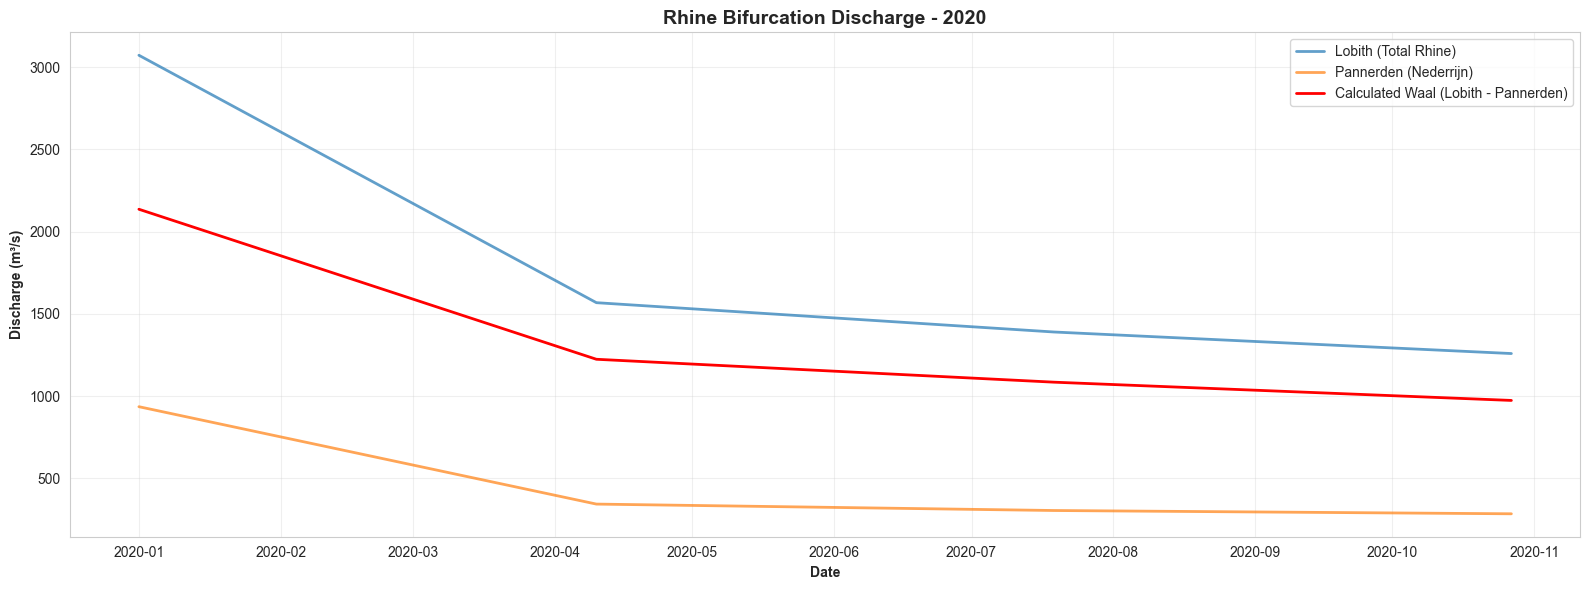


💡 RECOMMENDATION:
   Use this mass balance approach for historical Waal discharge (2016-2024)
   For 2025+, use Millingen direct measurements


In [82]:
print("="*80)
print("MASS BALANCE APPROACH: WAAL = LOBITH - PANNERDEN")
print("="*80)

print("\n🧪 Testing if we can calculate Waal discharge from bifurcation stations...\n")

# Test for year 2020 (should have data for both)
test_year = 2020

stations_to_test = {
    'lobith.bovenrijn.tolkamer': 'Total Rhine (upstream)',
    'pannerden.pannerdenschkanaal': 'Nederrijn branch',
}

discharge_data = {}

for station_code, description in stations_to_test.items():
    print(f"📊 {station_code} ({description})")
    
    body = {
        "Locatie": {"Code": station_code},
        "AquoPlusWaarnemingMetadata": {
            "AquoMetadata": {
                "Compartiment": {"Code": "OW"},
                "Grootheid": {"Code": "Q"},
                "ProcesType": "meting"
            }
        },
        "Periode": {
            "Begindatumtijd": f"{test_year}-01-01T00:00:00.000+01:00",
            "Einddatumtijd": f"{test_year}-12-31T23:59:59.999+01:00"
        }
    }
    
    try:
        response = requests.post(OBSERVATIONS_ENDPOINT, json=body, headers=HEADERS, timeout=15)
        if response.status_code == 200:
            data = response.json()
            if data.get('Succesvol') and data.get('WaarnemingenLijst'):
                metingen = data['WaarnemingenLijst'][0].get('MetingenLijst', [])
                if metingen:
                    # Parse into DataFrame
                    records = []
                    for m in metingen:
                        records.append({
                            'timestamp': m['Tijdstip'],
                            'discharge': m['Meetwaarde'].get('Waarde_Numeriek')
                        })
                    df = pd.DataFrame(records)
                    df['timestamp'] = pd.to_datetime(df['timestamp'])
                    
                    discharge_data[station_code] = df
                    
                    print(f"   ✅ {len(df):,} measurements")
                    print(f"   Range: {df['discharge'].min():.0f} - {df['discharge'].max():.0f} m³/s")
                    print(f"   Average: {df['discharge'].mean():.0f} m³/s\n")
                else:
                    print(f"   ⚠️  200 OK but 0 measurements\n")
        elif response.status_code == 204:
            print(f"   ❌ 204 (No Content)\n")
    except Exception as e:
        print(f"   ❌ Error: {e}\n")
    
    time.sleep(0.5)

# Calculate derived Waal discharge
if 'lobith.bovenrijn.tolkamer' in discharge_data and 'pannerden.pannerdenschkanaal' in discharge_data:
    print("="*80)
    print("CALCULATING WAAL DISCHARGE")
    print("="*80)
    
    lobith_df = discharge_data['lobith.bovenrijn.tolkamer'].copy()
    pannerden_df = discharge_data['pannerden.pannerdenschkanaal'].copy()
    
    # Merge on timestamp
    merged = pd.merge(
        lobith_df,
        pannerden_df,
        on='timestamp',
        how='inner',
        suffixes=('_lobith', '_pannerden')
    )
    
    # Calculate Waal discharge
    merged['discharge_waal'] = merged['discharge_lobith'] - merged['discharge_pannerden']
    
    print(f"\n✅ Calculated Waal discharge for {len(merged):,} timestamps in {test_year}\n")
    print(f"📊 Waal discharge statistics:")
    print(f"   Min:  {merged['discharge_waal'].min():6.0f} m³/s")
    print(f"   Max:  {merged['discharge_waal'].max():6.0f} m³/s")
    print(f"   Mean: {merged['discharge_waal'].mean():6.0f} m³/s")
    print(f"   Std:  {merged['discharge_waal'].std():6.0f} m³/s\n")
    
    # Check for negative values (would indicate error)
    negative_count = (merged['discharge_waal'] < 0).sum()
    if negative_count > 0:
        print(f"⚠️  WARNING: {negative_count} negative values detected!")
        print(f"   This suggests timing mismatch or measurement errors\n")
    else:
        print(f"✅ All values positive - mass balance is valid!\n")
    
    # Show sample calculation
    print(f"📋 Sample calculations (first 5 timestamps):\n")
    print(merged[['timestamp', 'discharge_lobith', 'discharge_pannerden', 'discharge_waal']].head().to_string(index=False))
    
    # Visualization
    print(f"\n📈 Plotting discharge breakdown...")
    fig, ax = plt.subplots(figsize=(16, 6))
    
    sample = merged.iloc[::100]  # Sample every 100th point for clarity
    
    ax.plot(sample['timestamp'], sample['discharge_lobith'], label='Lobith (Total Rhine)', linewidth=2, alpha=0.7)
    ax.plot(sample['timestamp'], sample['discharge_pannerden'], label='Pannerden (Nederrijn)', linewidth=2, alpha=0.7)
    ax.plot(sample['timestamp'], sample['discharge_waal'], label='Calculated Waal (Lobith - Pannerden)', linewidth=2, color='red')
    
    ax.set_xlabel('Date', fontweight='bold')
    ax.set_ylabel('Discharge (m³/s)', fontweight='bold')
    ax.set_title(f'Rhine Bifurcation Discharge - {test_year}', fontweight='bold', fontsize=14)
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 RECOMMENDATION:")
    print("   Use this mass balance approach for historical Waal discharge (2016-2024)")
    print("   For 2025+, use Millingen direct measurements")
else:
    print("\n❌ Cannot calculate - missing data from one or both stations")

## 8. Test Query for Selected Parameters

Validate that we can actually retrieve time series data for our priority parameters.

In [63]:
print("="*80)
print("QUICK ACTIVITY CHECK - JANUARY 1ST TEST")
print("="*80)

print(f"\n📋 Testing data availability on January 1st for years 2016-2025")
print(f"   This validates which stations have active time series data\n")

def quick_activity_test(station_code, parameter_desc, year):
    """
    Check if station has measurements on January 1st of given year.
    Returns: number of measurements (0 if none, -1 if error)
    """
    # Map parameter description to API parameter code
    if 'Waterhoogte' in parameter_desc:
        param_code = 'WATHTE'
    elif 'Debiet' in parameter_desc:
        param_code = 'Q'
    else:
        return -1
    
    body = {
        "Locatie": {"Code": station_code},
        "AquoPlusWaarnemingMetadata": {
            "AquoMetadata": {
                "Compartiment": {"Code": "OW"},
                "Grootheid": {"Code": param_code},
                "ProcesType": "meting"
            }
        },
        "Periode": {
            "Begindatumtijd": f"{year}-01-01T00:00:00.000+01:00",
            "Einddatumtijd": f"{year}-01-01T23:59:59.999+01:00"
        }
    }
    
    try:
        response = requests.post(OBSERVATIONS_ENDPOINT, json=body, headers=HEADERS, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if data.get('Succesvol'):
                waarnemingen = data.get('WaarnemingenLijst', [])
                if waarnemingen:
                    metingen = waarnemingen[0].get('MetingenLijst', [])
                    return len(metingen)
        return 0
    except:
        return -1

# Test parameters - USE ALL STATIONS
test_years = range(2016, 2026)  # 2016-2025
test_stations = {
    'water_height': parameter_stations['water_height'][['CODE', 'NAAM', 'PARAMETER_WAT_OMSCHRIJVING']].drop_duplicates('CODE'),
    'discharge': parameter_stations['discharge'][['CODE', 'NAAM', 'PARAMETER_WAT_OMSCHRIJVING']].drop_duplicates('CODE')
}

total_stations = len(test_stations['water_height']) + len(test_stations['discharge'])
total_calls = total_stations * len(test_years)

print(f"🧪 Testing ALL stations:")
print(f"   Water height: {len(test_stations['water_height'])} stations")
print(f"   Discharge: {len(test_stations['discharge'])} stations")
print(f"   Years: 2016-2025 (10 years)")
print(f"   Total API calls: {total_calls:,}")
print(f"   Estimated time: ~{total_calls * 0.35 / 60:.1f} minutes\n")

print("⏳ Running tests...\n")

results = []
station_count = 0

for param_type, stations_df in test_stations.items():
    print(f"\n{'='*60}")
    print(f"Testing {param_type.upper()} stations")
    print(f"{'='*60}\n")
    
    for _, row in stations_df.iterrows():
        station_count += 1
        station_code = row['CODE']
        station_name = row['NAAM']
        param_desc = row['PARAMETER_WAT_OMSCHRIJVING']
        
        print(f"[{station_count}/{total_stations}] {station_code:40s} ", end='', flush=True)
        
        year_results = {}
        for year in test_years:
            count = quick_activity_test(station_code, param_desc, year)
            year_results[year] = count
        
        results.append({
            'Station_Code': station_code,
            'Station_Name': station_name,
            'Parameter_Type': param_type,
            'Parameter_Description': param_desc[:60],
            **{f'Jan1_{year}': year_results[year] for year in test_years},
            'Total_Years_With_Data': sum(1 for c in year_results.values() if c > 0),
            'Avg_Measurements_Per_Day': np.mean([c for c in year_results.values() if c > 0]) if any(c > 0 for c in year_results.values()) else 0
        })
        
        # Show summary
        active_years = [year for year, count in year_results.items() if count > 0]
        if active_years:
            print(f"✅ {len(active_years)}/10 years active ({min(active_years)}-{max(active_years)})")
        else:
            print(f"❌ No data")
        
        time.sleep(0.3)  # Be polite to API

# Create results DataFrame
results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

# Overall statistics
print(f"\n📊 Activity Overview:\n")
print(f"   Total stations tested: {len(results_df)}")
print(f"   Stations with ANY data: {(results_df['Total_Years_With_Data'] > 0).sum()}")
print(f"   Stations with 8+ years: {(results_df['Total_Years_With_Data'] >= 8).sum()}")
print(f"   Stations with 0 data: {(results_df['Total_Years_With_Data'] == 0).sum()}\n")

# By parameter type
for param_type in ['water_height', 'discharge']:
    subset = results_df[results_df['Parameter_Type'] == param_type]
    print(f"📍 {param_type.upper()}:")
    print(f"   Tested: {len(subset)}")
    print(f"   With data: {(subset['Total_Years_With_Data'] > 0).sum()}")
    print(f"   Reliable (8+ years): {(subset['Total_Years_With_Data'] >= 8).sum()}\n")

# Year-by-year summary
print(f"📅 Data availability by year:")
for year in test_years:
    col = f'Jan1_{year}'
    active_count = (results_df[col] > 0).sum()
    pct = (active_count / len(results_df)) * 100
    print(f"   {year}: {active_count:3d}/{len(results_df)} stations ({pct:5.1f}%)")

# Save results
results_path = OUTPUT_DIR / "activity_test_jan1_all_stations.csv"
results_df.to_csv(results_path, index=False)
print(f"\n💾 Results saved to: {results_path}")

print(f"\n💡 Recommendation:")
print(f"   • Use stations with 8+ active years for reliable 2016-2025 analysis")
print(f"   • Stations with <5 years: Use with caution or exclude")

QUICK ACTIVITY CHECK - JANUARY 1ST TEST

📋 Testing data availability on January 1st for years 2016-2025
   This validates which stations have active time series data

🧪 Testing ALL stations:
   Water height: 226 stations
   Discharge: 19 stations
   Years: 2016-2025 (10 years)
   Total API calls: 2,450
   Estimated time: ~14.3 minutes

⏳ Running tests...


Testing WATER_HEIGHT stations

[1/245] negenoord.oost                           ✅ 10/10 years active (2016-2025)
[2/245] elsloo.maas                              ✅ 10/10 years active (2016-2025)
[3/245] eisdenmazenhove.maas                     ✅ 7/10 years active (2016-2022)
[4/245] rotem                                    ❌ No data
[5/245] nijmegen.waal                            ✅ 10/10 years active (2016-2025)
[6/245] negenoord.west                           ✅ 10/10 years active (2016-2025)
[7/245] kampen.ijssel                            ✅ 10/10 years active (2016-2025)
[8/245] buggenum                                 ✅ 10/10 yea

In [66]:
print("="*80)
print("DISCHARGE TIME SERIES VISUALIZATION")
print("="*80)

# Load test results
test_results_df = pd.read_csv(OUTPUT_DIR / "activity_test_jan1_all_stations.csv")

print(f"\n📋 CSV columns: {list(test_results_df.columns)}\n")

# Show sample
print(test_results_df.head())

# Filter for reliable discharge stations (8+ years) - assuming discharge is identified by parameter name
discharge_df = test_results_df[test_results_df['Total_Years_With_Data'] >= 8]

# Get discharge stations (those that were tested after water height stations)
# From your output, discharge testing started at row 227, so we can use station codes
reliable_discharge_codes = [
    'maastricht.borgharen.maas.beneden',
    'genemuiden', 
    'megen.maas',
    'pannerden.pannerdenschkanaal',
    'lobith.bovenrijn.tolkamer',
    'venlo',
    'olst',
    'maaseik',
    'driel.boven',
    'hagestein.boven',
    'hank.bergschemaas',
    'westervoort.ijsselkop'
]

# Pick 3 random stations
import random
random.seed(42)  # For reproducibility
sample_codes = random.sample(reliable_discharge_codes, 3)

print(f"📊 Selected discharge stations for visualization:")
for code in sample_codes:
    print(f"   • {code}")

DISCHARGE TIME SERIES VISUALIZATION

📋 CSV columns: ['Station_Code', 'Station_Name', 'Parameter_Type', 'Parameter_Description', 'Jan1_2016', 'Jan1_2017', 'Jan1_2018', 'Jan1_2019', 'Jan1_2020', 'Jan1_2021', 'Jan1_2022', 'Jan1_2023', 'Jan1_2024', 'Jan1_2025', 'Total_Years_With_Data', 'Avg_Measurements_Per_Day']

           Station_Code            Station_Name Parameter_Type  \
0        negenoord.oost         Negenoord, oost   water_height   
1           elsloo.maas            Elsloo, Maas   water_height   
2  eisdenmazenhove.maas  Eisden Mazenhove, Maas   water_height   
3                 rotem                   Rotem   water_height   
4         nijmegen.waal          Nijmegen, Waal   water_height   

                               Parameter_Description  Jan1_2016  Jan1_2017  \
0  Waterhoogte in Oppervlaktewater t.o.v. Normaal...        144        144   
1  Waterhoogte in Oppervlaktewater t.o.v. Normaal...        144        144   
2  Waterhoogte in Oppervlaktewater t.o.v. Normaal...     

In [67]:
print("⏳ Fetching full time series data for discharge stations...\n")

# Selected stations from above
viz_stations = ['hank.bergschemaas', 'genemuiden', 'maastricht.borgharen.maas.beneden']

# Fetch chunked data function (from earlier notebooks)
def fetch_discharge_data_chunked(station_code, start_year=2016, end_year=2025):
    """Fetch discharge data year by year to avoid API rate limiting."""
    all_data = []
    
    for year in range(start_year, end_year + 1):
        body = {
            "Locatie": {"Code": station_code},
            "AquoPlusWaarnemingMetadata": {
                "AquoMetadata": {
                    "Compartiment": {"Code": "OW"},
                    "Grootheid": {"Code": "Q"},
                    "ProcesType": "meting"
                }
            },
            "Periode": {
                "Begindatumtijd": f"{year}-01-01T00:00:00.000+01:00",
                "Einddatumtijd": f"{year}-12-31T23:59:59.999+01:00"
            }
        }
        
        try:
            response = requests.post(OBSERVATIONS_ENDPOINT, json=body, headers=HEADERS, timeout=30)
            if response.status_code == 200:
                data = response.json()
                if data.get('Succesvol') and data.get('WaarnemingenLijst'):
                    waarnemingen = data['WaarnemingenLijst']
                    if waarnemingen and waarnemingen[0].get('MetingenLijst'):
                        metingen = waarnemingen[0]['MetingenLijst']
                        for meting in metingen:
                            timestamp = meting.get('Tijdstip')
                            meetwaarde = meting.get('Meetwaarde', {})
                            discharge = meetwaarde.get('Waarde_Numeriek') if isinstance(meetwaarde, dict) else None
                            
                            if timestamp and discharge is not None:
                                all_data.append({
                                    'timestamp': timestamp,
                                    'discharge_m3s': discharge,
                                    'station_code': station_code
                                })
        except Exception as e:
            print(f"   Error fetching {year}: {e}")
        
        time.sleep(0.3)
    
    if all_data:
        df = pd.DataFrame(all_data)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['year'] = df['timestamp'].dt.year
        df['month'] = df['timestamp'].dt.month
        df['day'] = df['timestamp'].dt.day
        df['hour'] = df['timestamp'].dt.hour
        return df
    return None

# Fetch data
discharge_data = {}
for station in viz_stations:
    print(f"Fetching {station}...")
    df = fetch_discharge_data_chunked(station)
    if df is not None and len(df) > 0:
        discharge_data[station] = df
        print(f"   ✅ {len(df):,} measurements ({df['year'].min()}-{df['year'].max()})\n")
    else:
        print(f"   ❌ No data\n")

print(f"✅ Successfully fetched data for {len(discharge_data)} stations\n")

⏳ Fetching full time series data for discharge stations...

Fetching hank.bergschemaas...
   ✅ 473,472 measurements (2016-2024)

Fetching genemuiden...
   ✅ 482,737 measurements (2016-2025)

Fetching maastricht.borgharen.maas.beneden...
   ✅ 482,778 measurements (2016-2025)

✅ Successfully fetched data for 3 stations



DISCHARGE VISUALIZATIONS

📊 Creating yearly average discharge plots...



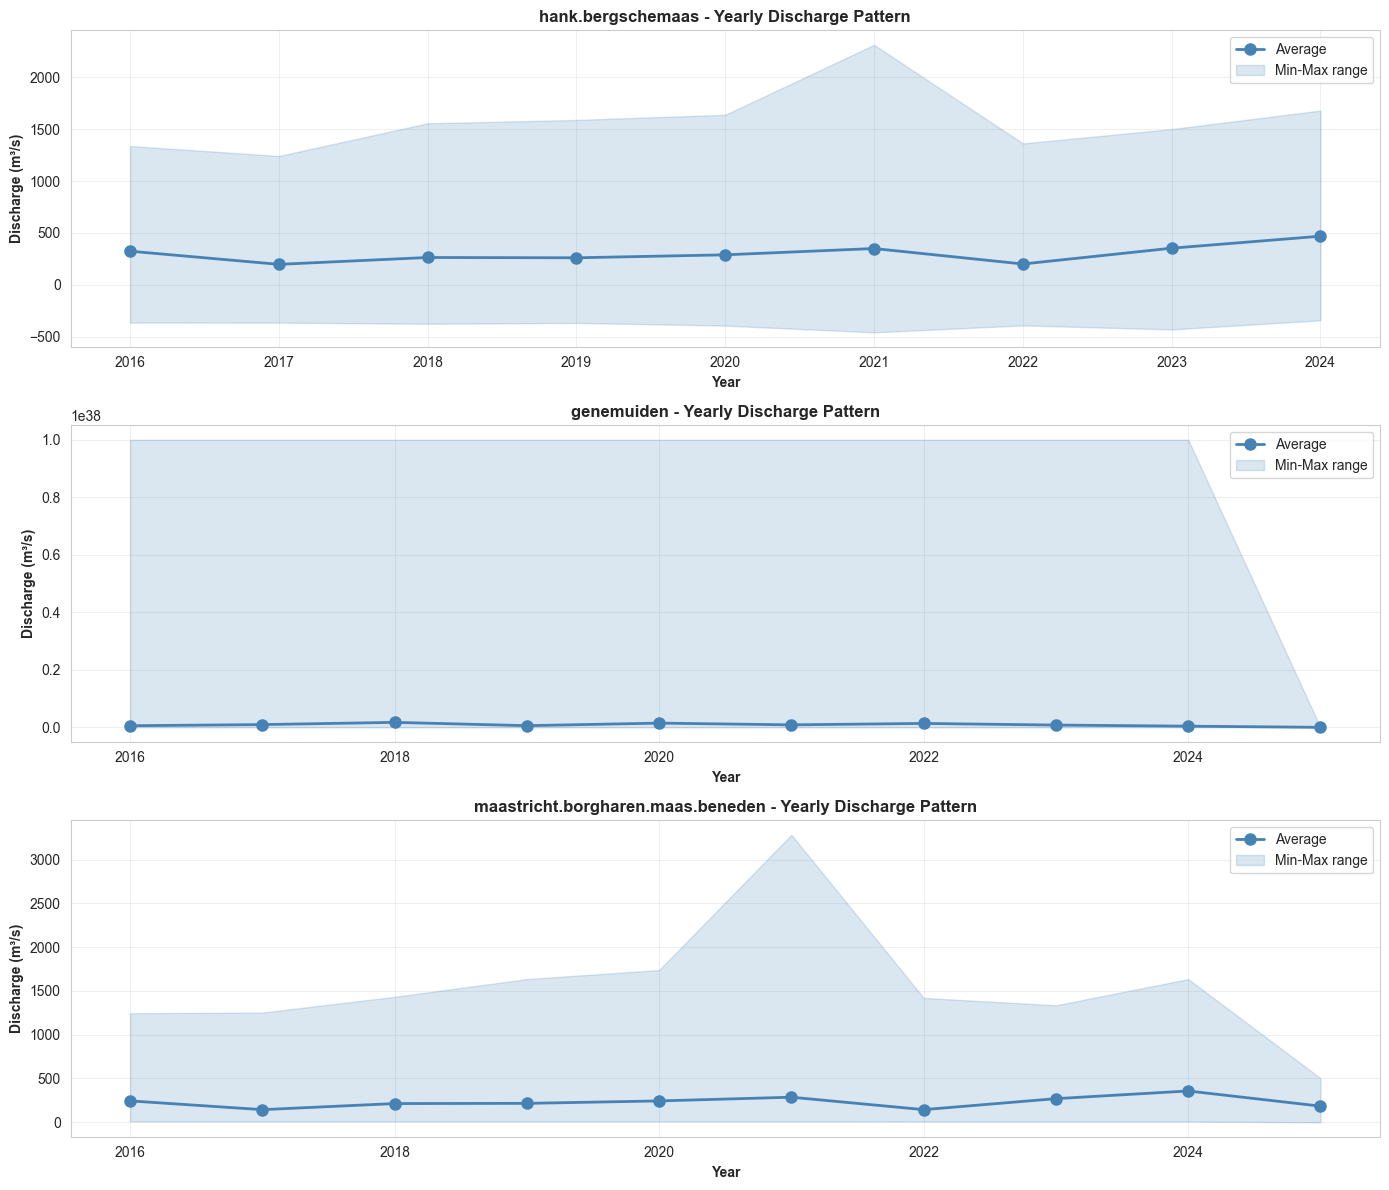


📊 Creating monthly discharge patterns...



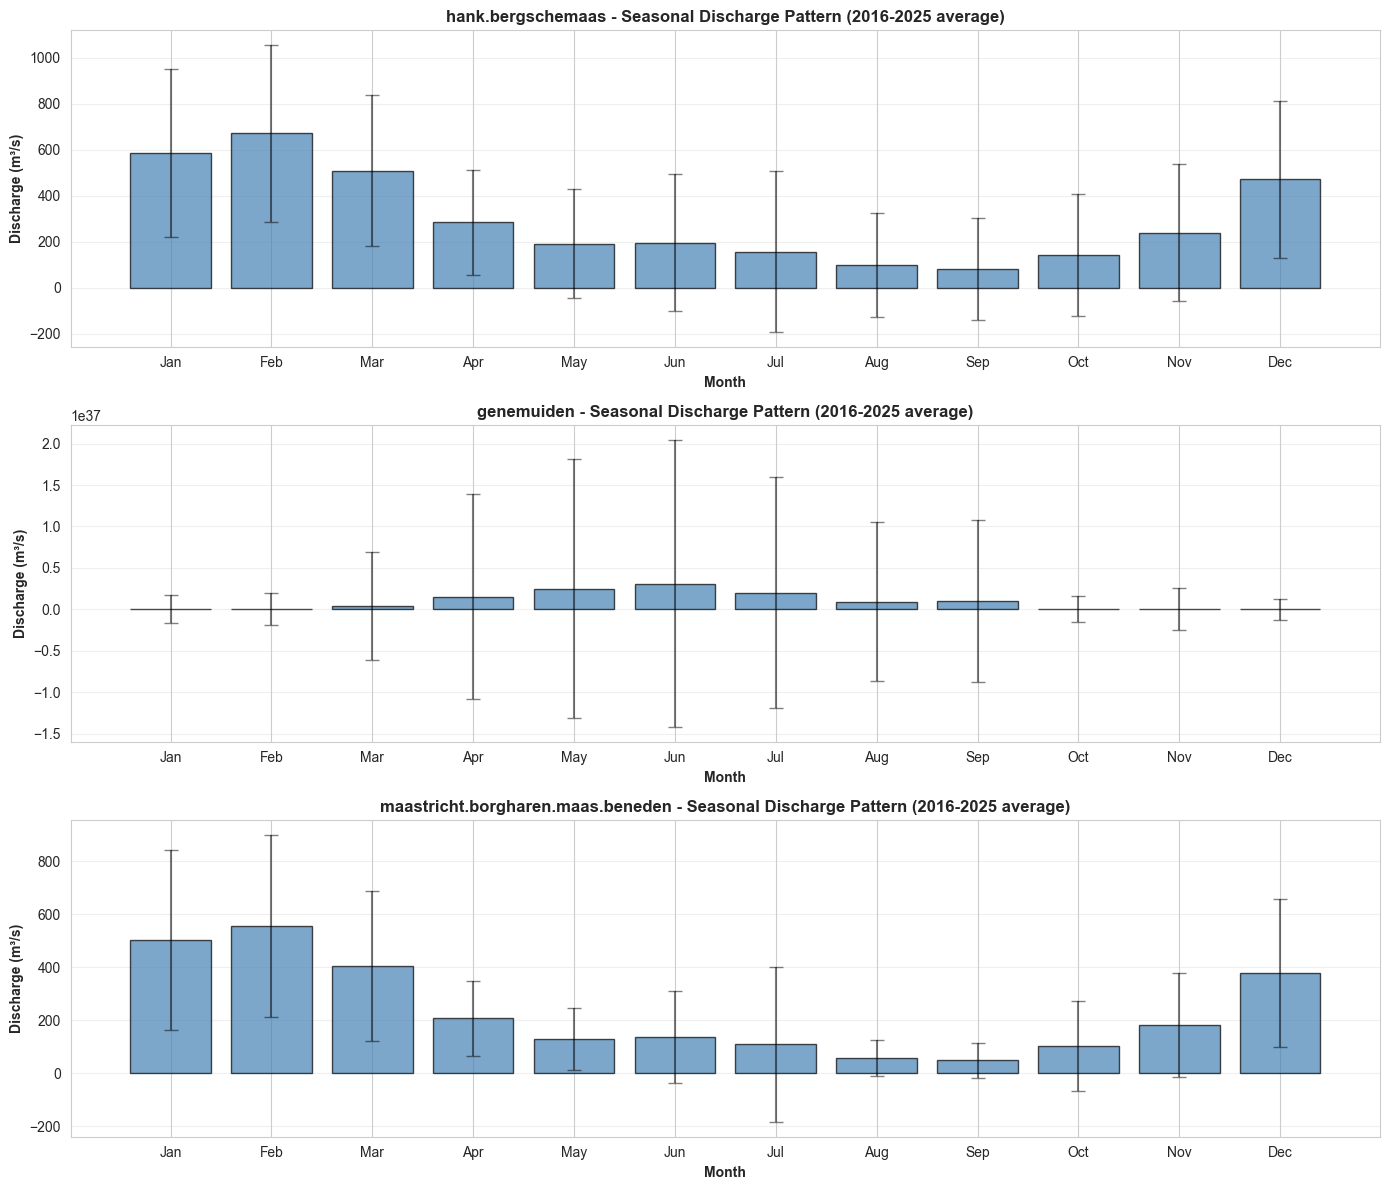


📊 Creating daily discharge plots for selected periods...



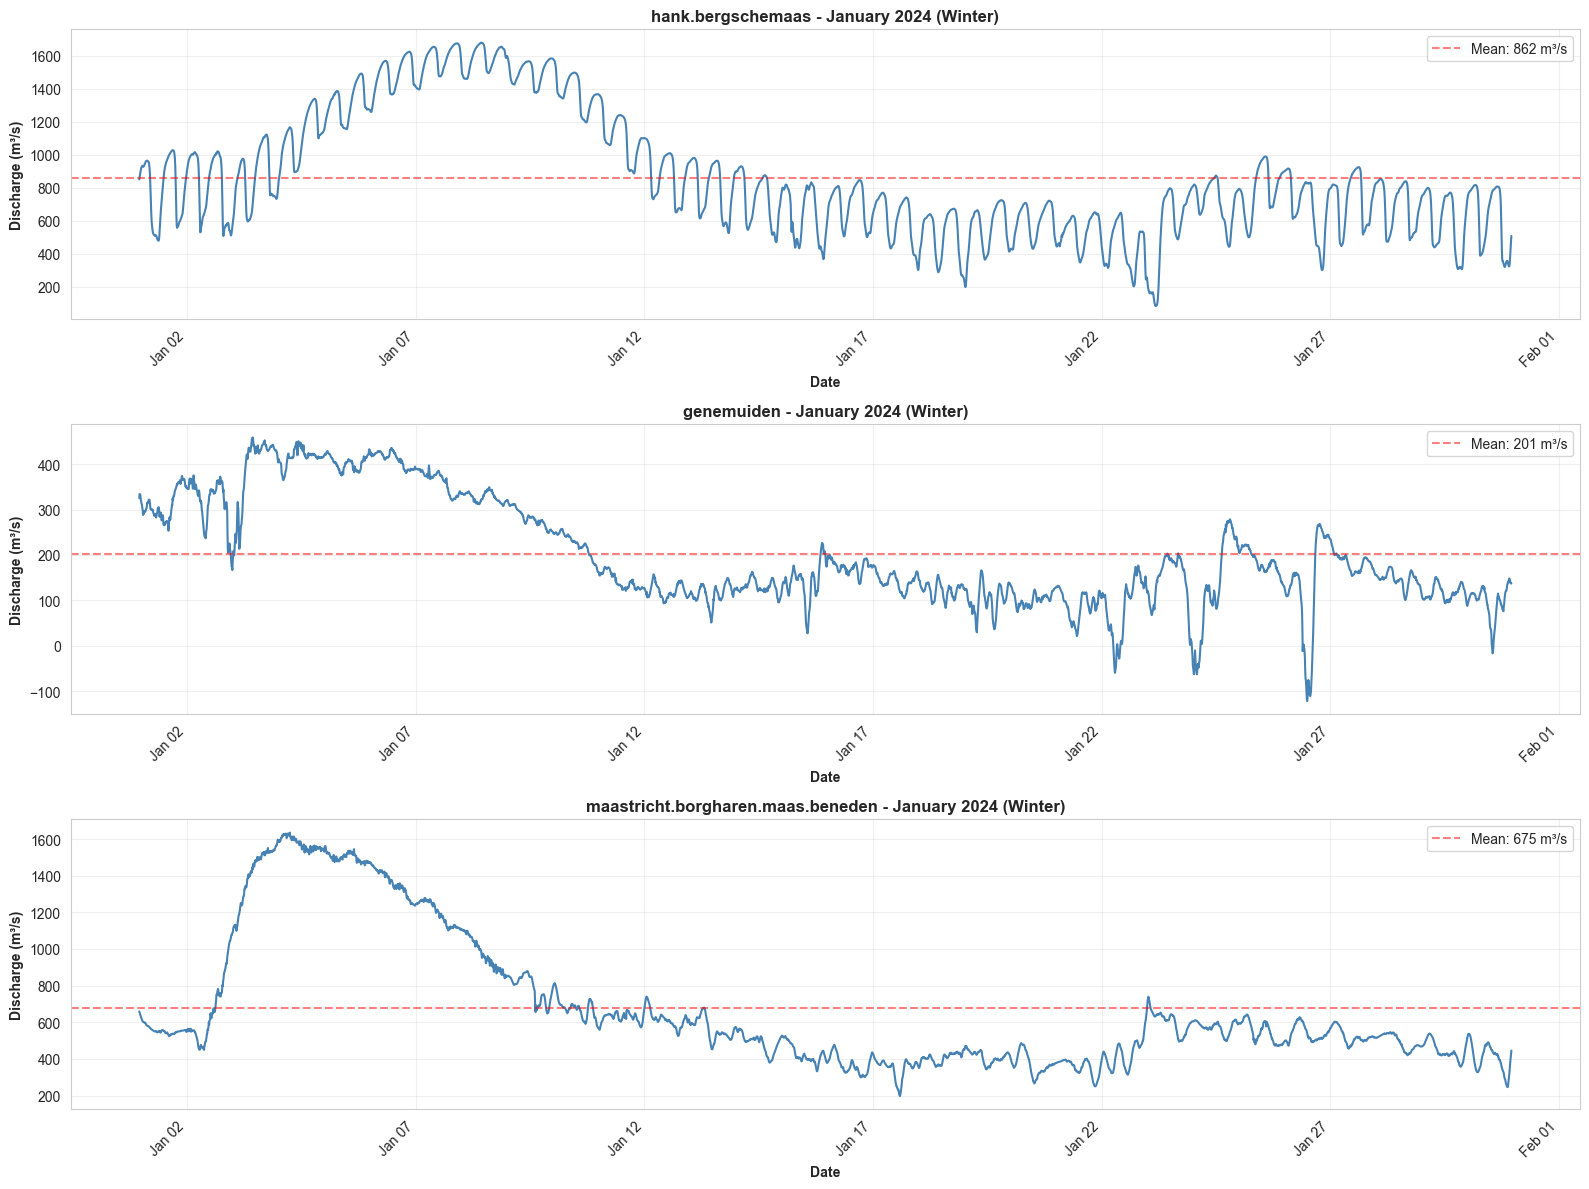

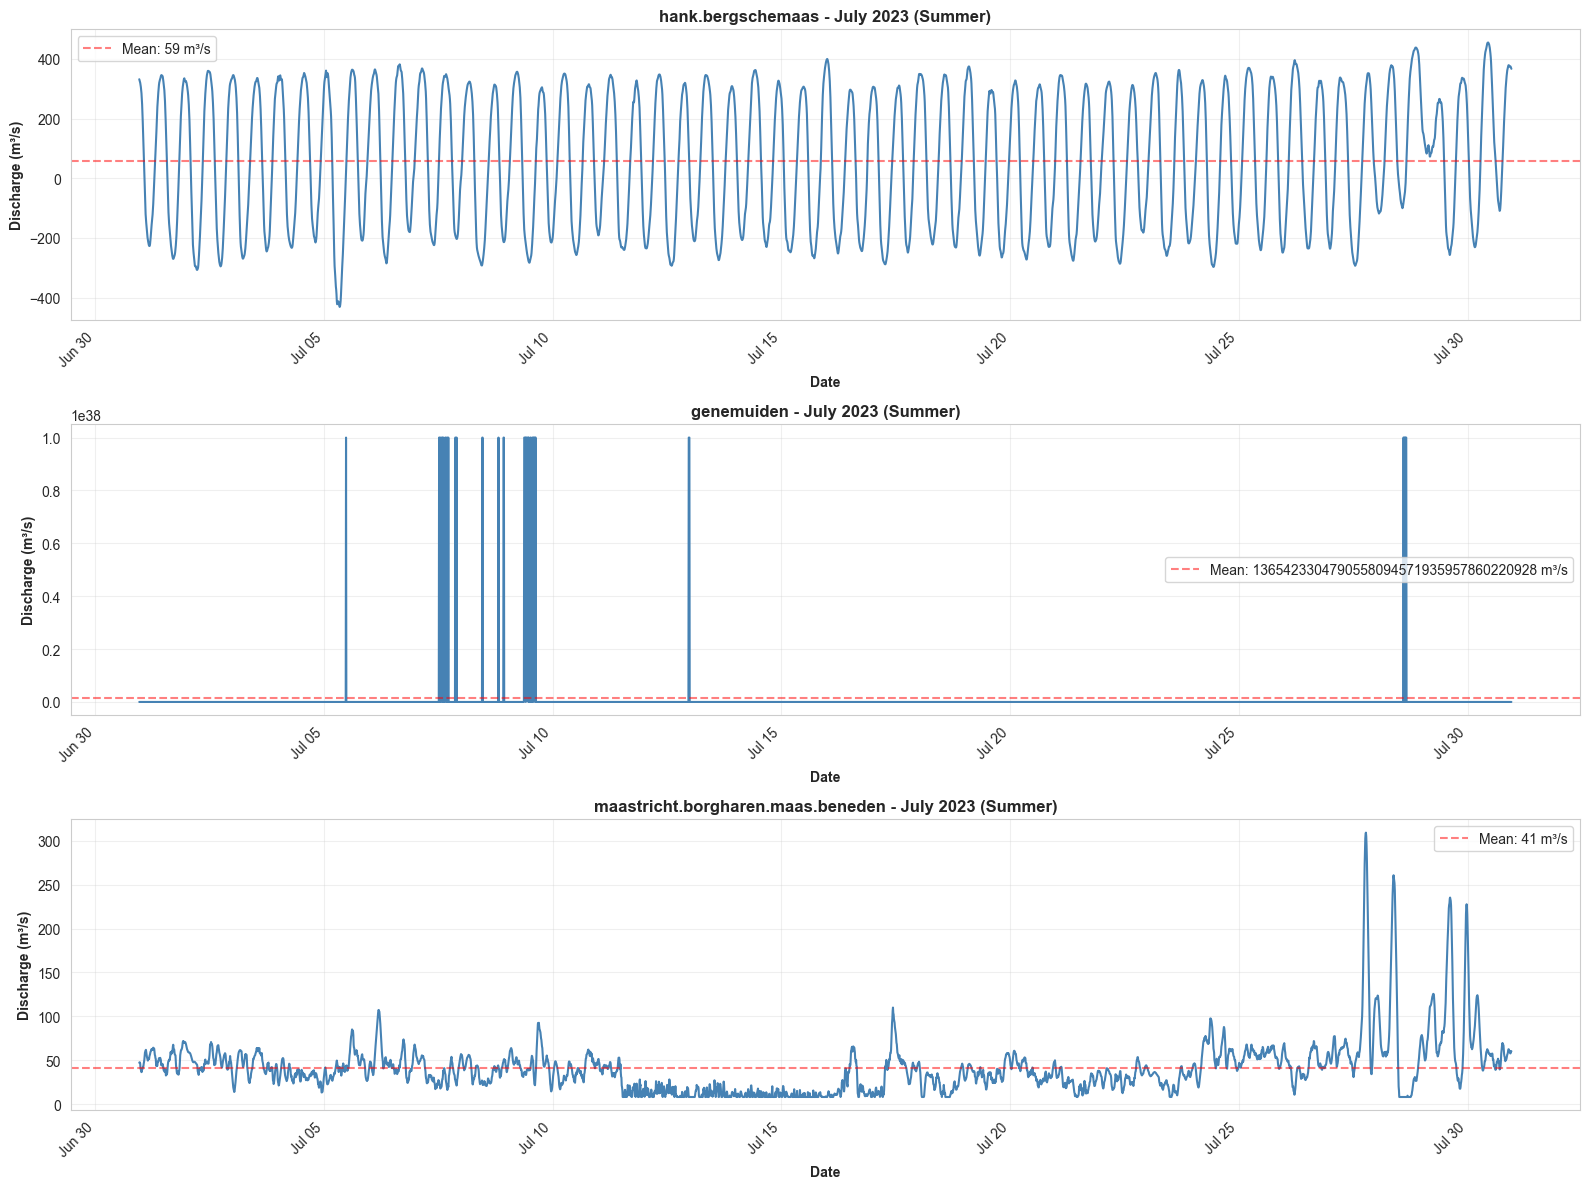

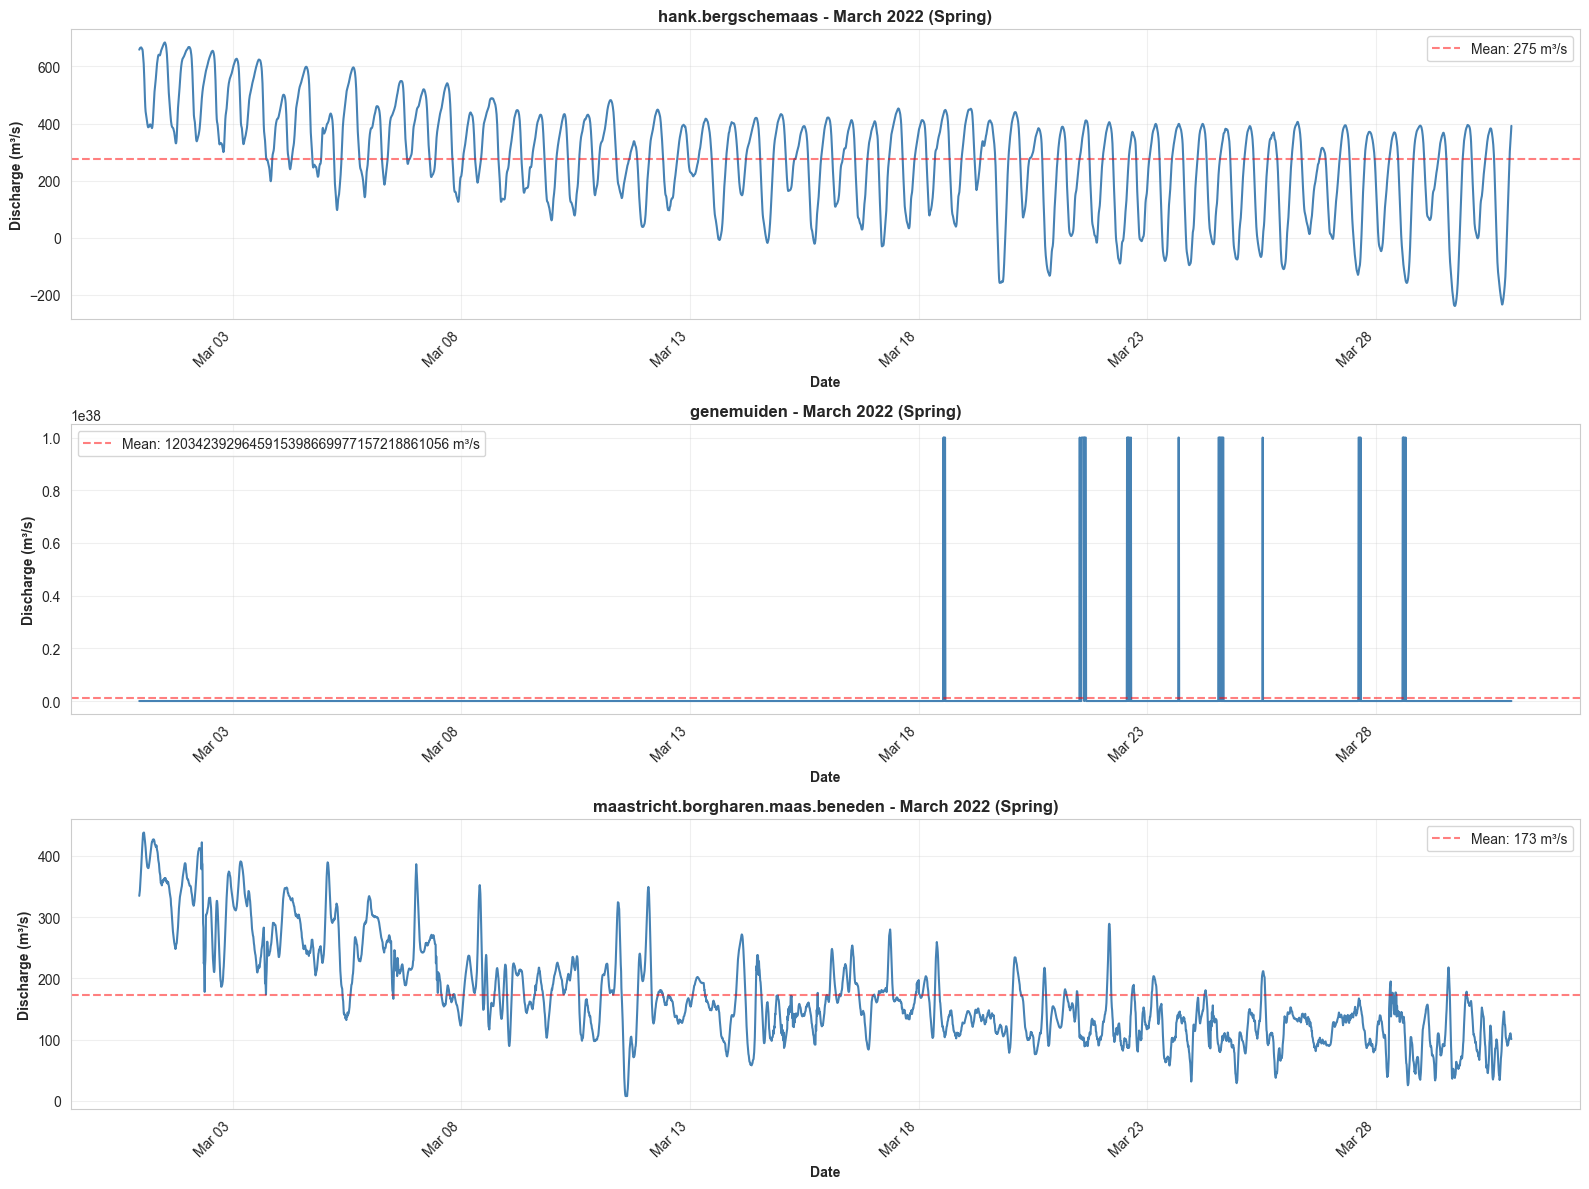


✅ All visualizations complete!


In [68]:
print("="*80)
print("DISCHARGE VISUALIZATIONS")
print("="*80)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. YEARLY PATTERNS
print("\n📊 Creating yearly average discharge plots...\n")

fig, axes = plt.subplots(len(discharge_data), 1, figsize=(14, 4*len(discharge_data)))
if len(discharge_data) == 1:
    axes = [axes]

for idx, (station, df) in enumerate(discharge_data.items()):
    ax = axes[idx]
    
    # Calculate yearly average
    yearly_avg = df.groupby('year')['discharge_m3s'].mean()
    yearly_max = df.groupby('year')['discharge_m3s'].max()
    yearly_min = df.groupby('year')['discharge_m3s'].min()
    
    ax.plot(yearly_avg.index, yearly_avg.values, 'o-', linewidth=2, markersize=8, label='Average', color='steelblue')
    ax.fill_between(yearly_avg.index, yearly_min.values, yearly_max.values, alpha=0.2, color='steelblue', label='Min-Max range')
    
    ax.set_title(f'{station} - Yearly Discharge Pattern', fontweight='bold', fontsize=12)
    ax.set_xlabel('Year', fontweight='bold')
    ax.set_ylabel('Discharge (m³/s)', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# 2. MONTHLY PATTERNS (average across all years)
print("\n📊 Creating monthly discharge patterns...\n")

fig, axes = plt.subplots(len(discharge_data), 1, figsize=(14, 4*len(discharge_data)))
if len(discharge_data) == 1:
    axes = [axes]

for idx, (station, df) in enumerate(discharge_data.items()):
    ax = axes[idx]
    
    # Calculate monthly average across all years
    monthly_avg = df.groupby('month')['discharge_m3s'].mean()
    monthly_std = df.groupby('month')['discharge_m3s'].std()
    
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    ax.bar(range(1, 13), monthly_avg.values, color='steelblue', alpha=0.7, edgecolor='black')
    ax.errorbar(range(1, 13), monthly_avg.values, yerr=monthly_std.values, fmt='none', color='black', capsize=5, alpha=0.5)
    
    ax.set_title(f'{station} - Seasonal Discharge Pattern (2016-2025 average)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Month', fontweight='bold')
    ax.set_ylabel('Discharge (m³/s)', fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. DAILY PATTERNS (sample periods)
print("\n📊 Creating daily discharge plots for selected periods...\n")

# Select 3 interesting periods: winter high water, summer low water, spring transition
periods = [
    ('2024-01-01', '2024-01-31', 'January 2024 (Winter)'),
    ('2023-07-01', '2023-07-31', 'July 2023 (Summer)'),
    ('2022-03-01', '2022-03-31', 'March 2022 (Spring)')
]

for period_start, period_end, period_name in periods:
    fig, axes = plt.subplots(len(discharge_data), 1, figsize=(16, 4*len(discharge_data)))
    if len(discharge_data) == 1:
        axes = [axes]
    
    for idx, (station, df) in enumerate(discharge_data.items()):
        ax = axes[idx]
        
        # Filter for period
        mask = (df['timestamp'] >= period_start) & (df['timestamp'] <= period_end)
        period_df = df[mask].copy()
        
        if len(period_df) > 0:
            ax.plot(period_df['timestamp'], period_df['discharge_m3s'], linewidth=1.5, color='steelblue')
            
            ax.set_title(f'{station} - {period_name}', fontweight='bold', fontsize=12)
            ax.set_xlabel('Date', fontweight='bold')
            ax.set_ylabel('Discharge (m³/s)', fontweight='bold')
            ax.grid(alpha=0.3)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
            
            # Add mean line
            mean_val = period_df['discharge_m3s'].mean()
            ax.axhline(mean_val, color='red', linestyle='--', alpha=0.5, label=f'Mean: {mean_val:.0f} m³/s')
            ax.legend()
        else:
            ax.text(0.5, 0.5, 'No data for this period', ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    plt.show()
    print()

print("✅ All visualizations complete!")

## 9. Save GeoPackages by Parameter Type

Create separate GeoPackage files for each priority parameter.

In [72]:
print("="*80)
print("SAVING GEOPACKAGE")
print("="*80)

print(f"\n📦 Creating unified GeoPackage with multiple layers...\n")

# Get reliable stations from test results
test_results_df = pd.read_csv(OUTPUT_DIR / "activity_test_jan1_all_stations.csv")

reliable_wathte = test_results_df[
    (test_results_df['Parameter_Type'] == 'water_height') &
    (test_results_df['Total_Years_With_Data'] >= 8)
]['Station_Code'].tolist()

reliable_discharge = test_results_df[
    (test_results_df['Parameter_Type'] == 'discharge') &
    (test_results_df['Total_Years_With_Data'] >= 8)
]['Station_Code'].tolist()

print(f"📊 Reliable stations:")
print(f"   • Water height: {len(reliable_wathte)}")
print(f"   • Discharge: {len(reliable_discharge)}\n")

# Output path
OUTPUT_GPKG = OUTPUT_DIR / "water_stations_reliable.gpkg"

# 1. Water height stations
wathte_gdf = parameter_stations['water_height'][
    parameter_stations['water_height']['CODE'].isin(reliable_wathte)
].drop_duplicates(subset='CODE').copy()

# Drop FID if it exists (conflicts with GeoPackage auto-generated FID)
if 'FID' in wathte_gdf.columns:
    wathte_gdf = wathte_gdf.drop(columns=['FID'])

wathte_gdf.to_file(OUTPUT_GPKG, layer='water_height_stations', driver='GPKG')
print(f"   ✅ water_height_stations: {len(wathte_gdf)} stations")

# 2. Discharge stations
discharge_gdf = parameter_stations['discharge'][
    parameter_stations['discharge']['CODE'].isin(reliable_discharge)
].drop_duplicates(subset='CODE').copy()

# Drop FID if it exists
if 'FID' in discharge_gdf.columns:
    discharge_gdf = discharge_gdf.drop(columns=['FID'])

discharge_gdf.to_file(OUTPUT_GPKG, layer='discharge_stations', driver='GPKG')
print(f"   ✅ discharge_stations: {len(discharge_gdf)} stations")

# 3. Multi-parameter stations (have both water height AND discharge)
overlap_codes = set(reliable_wathte) & set(reliable_discharge)
if overlap_codes:
    multi_gdf = wathte_gdf[wathte_gdf['CODE'].isin(overlap_codes)].copy()
    multi_gdf.to_file(OUTPUT_GPKG, layer='multi_parameter_stations', driver='GPKG')
    print(f"   ✅ multi_parameter_stations: {len(multi_gdf)} stations\n")

print(f"\n{'='*80}")
print(f"✅ GEOPACKAGE SAVED SUCCESSFULLY!")
print(f"{'='*80}")
print(f"\n📂 Location: {OUTPUT_GPKG}")
print(f"\n📊 Layers:")
print(f"   • water_height_stations: {len(wathte_gdf)} reliable stations (8+ years)")
print(f"   • discharge_stations: {len(discharge_gdf)} reliable stations (8+ years)")
if overlap_codes:
    print(f"   • multi_parameter_stations: {len(overlap_codes)} stations with both parameters")

SAVING GEOPACKAGE

📦 Creating unified GeoPackage with multiple layers...

📊 Reliable stations:
   • Water height: 66
   • Discharge: 12

   ✅ water_height_stations: 66 stations
   ✅ discharge_stations: 12 stations
   ✅ multi_parameter_stations: 11 stations


✅ GEOPACKAGE SAVED SUCCESSFULLY!

📂 Location: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_by_parameter/water_stations_reliable.gpkg

📊 Layers:
   • water_height_stations: 66 reliable stations (8+ years)
   • discharge_stations: 12 reliable stations (8+ years)
   • multi_parameter_stations: 11 stations with both parameters


## 10. Summary & Next Steps

In [70]:
print("="*80)
print("DISCOVERY COMPLETE - SUMMARY")
print("="*80)

print(f"\n📊 Data Discovery Results:\n")
print(f"   • Total parameters discovered: {len(parameter_summary)}")
print(f"   • Parameters in scope regions: {len(scope_parameter_summary)}")
print(f"   • Active stations (unique locations): {active_stations['CODE'].nunique()}")
print(f"   • Priority parameters identified: {len(identified_params) if identified_params else 0}\n")

if identified_params:
    print(f"📋 Priority Parameters:\n")
    for param_type in identified_params.keys():
        count = coverage_df[param_type].sum() if coverage_df is not None else 0
        print(f"   • {param_type:20s}: {count} stations")

print(f"\n📁 Outputs saved to: {OUTPUT_DIR}\n")

print("="*80)
print("NEXT STEPS")
print("="*80)

print("\n1. Review the parameter inventory and coverage matrix")
print("2. Verify the GeoPackages in QGIS")
print("3. Create a separate notebook for bulk time series download")
print("4. Download historical data (2016-2025) for selected parameters")
print("5. Implement feature engineering for erosion modeling\n")

print("💡 Recommended parameters for erosion modeling:")
if identified_params:
    for param_type in ['water_height', 'discharge']:
        if param_type in identified_params:
            print(f"   ✅ {param_type} - Essential")
        else:
            print(f"   ❌ {param_type} - Not found (revisit parameter search)")
else:
    print("   ⚠️ No priority parameters identified - review search keywords")

print("\n" + "="*80)

DISCOVERY COMPLETE - SUMMARY

📊 Data Discovery Results:

   • Total parameters discovered: 2437
   • Parameters in scope regions: 1555
   • Active stations (unique locations): 0
   • Priority parameters identified: 2

📋 Priority Parameters:



NameError: name 'coverage_df' is not defined